# Pandas Indicator Tester (One-by-One)

Pure **pandas/numpy** technical indicators — no TA-Lib required.

Run setup cells once, then run any indicator cell below.

```bash
pip install -e ".[notebook]"
jupyter lab notebooks/pandas_indicator_tester.ipynb
```


In [11]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from indicator_testing.data_loader import describe_ohlc, load_ohlc
from indicator_testing.pandas_indicators import PandasIndicatorRegistry
from indicator_testing.pandas_runner import run_pandas_indicator

print(f"Project root: {PROJECT_ROOT}")


Project root: d:\Projects\Indicator Testing


## Configuration


In [12]:
CSV_PATH = PROJECT_ROOT / "questdb-query-1781940224994.csv"
RESAMPLE = "none"   # "none" | "daily" | "monthly" | "weekly"
SYMBOL = None


In [13]:
resample_arg = None if RESAMPLE == "none" else RESAMPLE
df = load_ohlc(CSV_PATH, resample=resample_arg, symbol=SYMBOL, warn_short=False)
registry = PandasIndicatorRegistry()
info = describe_ohlc(df)

print(f"Loaded {info['bars']} bars | {info['inferred_frequency']}")
print(f"Pandas indicators: {len(registry.all_names())}")
df.tail(3)


Loaded 19503 bars | intraday (minute/sub-minute)
Pandas indicators: 37


C:\Users\mohxm\AppData\Local\Temp\ipykernel_33976\241344708.py:2: UserWarning: Dropping 16500 duplicate timestamp(s), keeping last occurrence.
  df = load_ohlc(CSV_PATH, resample=resample_arg, symbol=SYMBOL, warn_short=False)
C:\Users\mohxm\AppData\Local\Temp\ipykernel_33976\241344708.py:2: UserWarning: Data looks intraday (~60s bars). Use --resample monthly or --resample daily for aggregated testing.
  df = load_ohlc(CSV_PATH, resample=resample_arg, symbol=SYMBOL, warn_short=False)


,open,high,low,close,volume
date,,,,,
2026-06-19 15:27:00+00:00,24027.5,24036.85,24023.10,24035.6,5888123
2026-06-19 15:28:00+00:00,24033.8,24043.15,24031.15,24042.1,3461609
2026-06-19 15:29:00+00:00,24037.4,24047.20,24034.90,24042.7,2148843


## Helpers


In [14]:
def show_validation(result):
    meta = registry.get(result.name)
    print(f"{'='*60}")
    print(f"{result.name}  |  {result.group}  (pandas)")
    print(f"Status: {result.status}  |  Warmup: {result.warmup_bars}")
    print(f"Outputs: {meta.output_names}  |  Params: {result.params_used}")
    if result.message and result.status != "success":
        print(f"Message: {result.message}")
    if result.validation:
        tag = "PASS" if result.validation.passed else "FAIL"
        print(f"Validation: {tag}")
        for c in result.validation.checks:
            mark = "OK" if c.passed else "X"
            print(f"  [{mark}] {c.name}: {c.message}")
    print(f"{'='*60}")


def result_to_frame(result, n_tail=15):
    if result.status != "success" or not result.outputs:
        return pd.DataFrame()
    out = pd.DataFrame({"close": df["close"]})
    for k, arr in result.outputs.items():
        out[k] = arr
    out.index = df.index
    return out.tail(n_tail)


def plot_pandas(result):
    if result.status != "success" or not result.outputs:
        print("Nothing to plot.")
        return
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(df.index, df["close"], label="Close", color="black", lw=1)
    axes[0].set_ylabel("Price")
    axes[0].legend(loc="upper left")
    for key, arr in result.outputs.items():
        axes[1].plot(df.index, arr, label=key, lw=1)
    axes[1].set_ylabel(result.name)
    axes[1].legend(loc="upper left")
    fig.suptitle(f"{result.name} (pandas) — {result.params_used}")
    fig.tight_layout()
    plt.show()


def test_pandas_indicator(name, params=None):
    result = run_pandas_indicator(name, df, registry, params=params)
    show_validation(result)
    display(result_to_frame(result))
    plot_pandas(result)
    return result


## Table of contents

- [Overlap Studies](#overlap-studies)
- [Momentum Indicators](#momentum-indicators)
- [Volatility Indicators](#volatility-indicators)
- [Volume Indicators](#volume-indicators)
- [Price Transform](#price-transform)
- [Statistic Functions](#statistic-functions)


<a id="overlap-studies"></a>
## Overlap Studies (7)


### SMA
Outputs: `['sma']` · Defaults: `{'length': 20}`


SMA  |  Overlap Studies  (pandas)
Status: success  |  Warmup: 19
Outputs: ['sma']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,sma
date,,
2026-06-19 15:15:00+00:00,24016.85,23992.2750
2026-06-19 15:16:00+00:00,24018.85,23997.7500
2026-06-19 15:17:00+00:00,24027.60,24003.5900
2026-06-19 15:18:00+00:00,24025.75,24009.6375
2026-06-19 15:19:00+00:00,24028.00,24015.5100
2026-06-19 15:20:00+00:00,24031.15,24019.3650
2026-06-19 15:21:00+00:00,24030.90,24022.5650
2026-06-19 15:22:00+00:00,24027.20,24024.2400
2026-06-19 15:23:00+00:00,24031.65,24025.9100


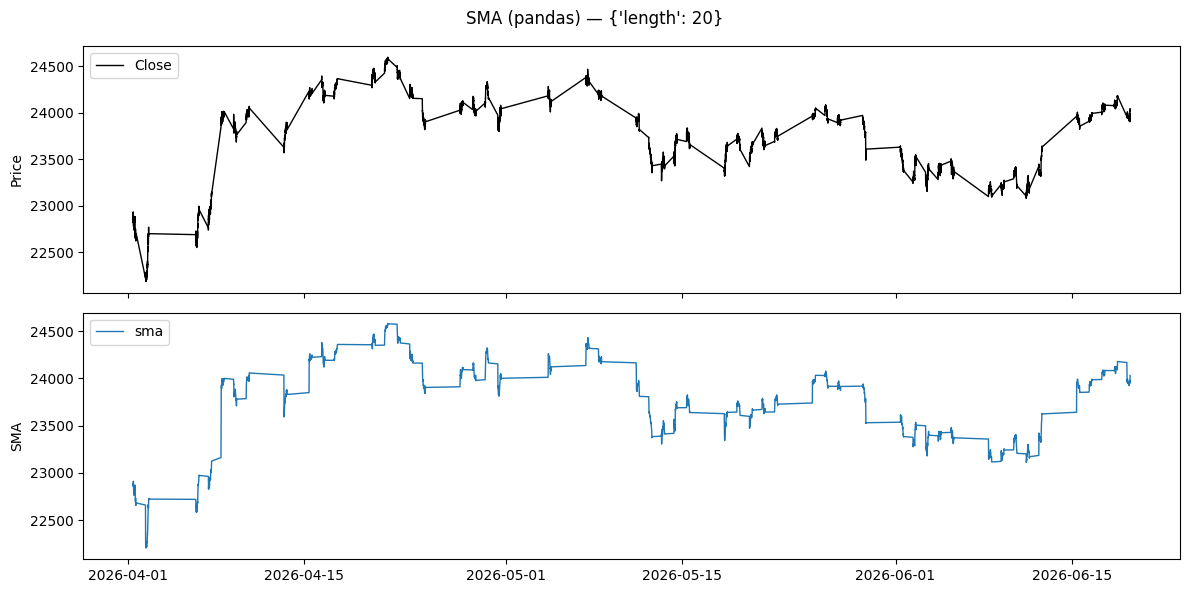

IndicatorResult(name='SMA', group='Overlap Studies', params_used={'length': 20}, outputs={'sma': array([       nan,        nan,        nan, ..., 24028.9025, 24029.845 ,
       24030.85  ])}, warmup_bars=19, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [15]:
test_pandas_indicator("SMA")


### EMA
Outputs: `['ema']` · Defaults: `{'length': 20}`


EMA  |  Overlap Studies  (pandas)
Status: success  |  Warmup: 0
Outputs: ['ema']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,ema
date,,
2026-06-19 15:15:00+00:00,24016.85,24004.440952
2026-06-19 15:16:00+00:00,24018.85,24005.813243
2026-06-19 15:17:00+00:00,24027.60,24007.888172
2026-06-19 15:18:00+00:00,24025.75,24009.589298
2026-06-19 15:19:00+00:00,24028.00,24011.342698
2026-06-19 15:20:00+00:00,24031.15,24013.229108
2026-06-19 15:21:00+00:00,24030.90,24014.912050
2026-06-19 15:22:00+00:00,24027.20,24016.082331
2026-06-19 15:23:00+00:00,24031.65,24017.564966


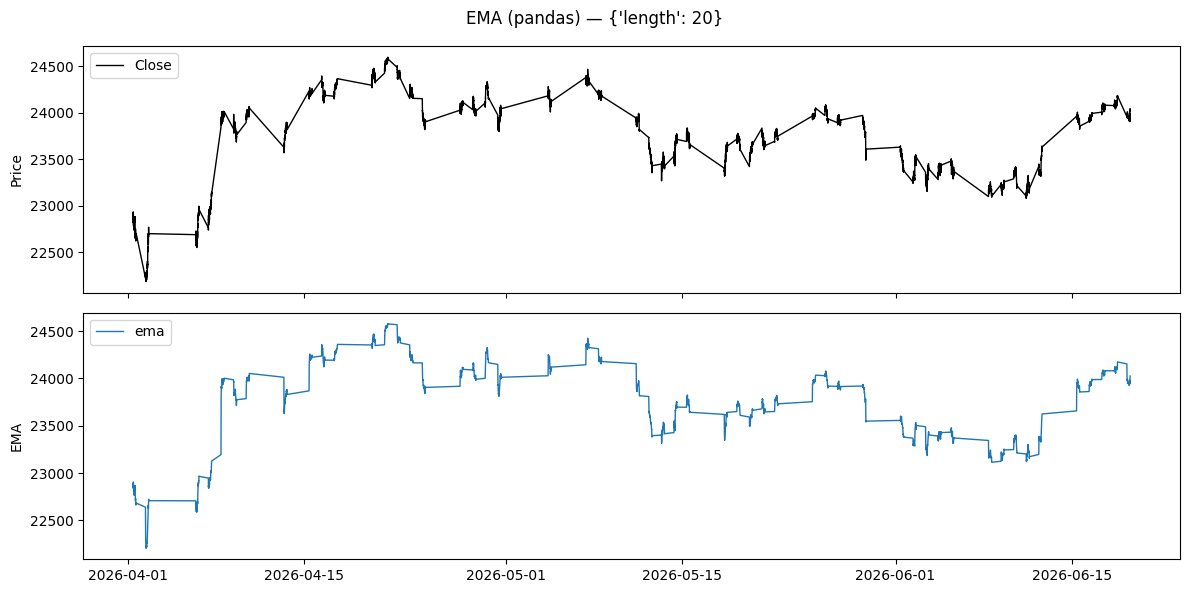

IndicatorResult(name='EMA', group='Overlap Studies', params_used={'length': 20}, outputs={'ema': array([22843.45      , 22841.60714286, 22844.2207483 , ...,
       24022.16247383, 24024.06128584, 24025.83640148])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [16]:
test_pandas_indicator("EMA")


### WMA
Outputs: `['wma']` · Defaults: `{'length': 20}`


WMA  |  Overlap Studies  (pandas)
Status: success  |  Warmup: 19
Outputs: ['wma']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,wma
date,,
2026-06-19 15:15:00+00:00,24016.85,24014.868810
2026-06-19 15:16:00+00:00,24018.85,24017.399762
2026-06-19 15:17:00+00:00,24027.60,24020.242619
2026-06-19 15:18:00+00:00,24025.75,24022.353095
2026-06-19 15:19:00+00:00,24028.00,24024.101905
2026-06-19 15:20:00+00:00,24031.15,24025.591429
2026-06-19 15:21:00+00:00,24030.90,24026.690000
2026-06-19 15:22:00+00:00,24027.20,24027.131429
2026-06-19 15:23:00+00:00,24031.65,24027.837143


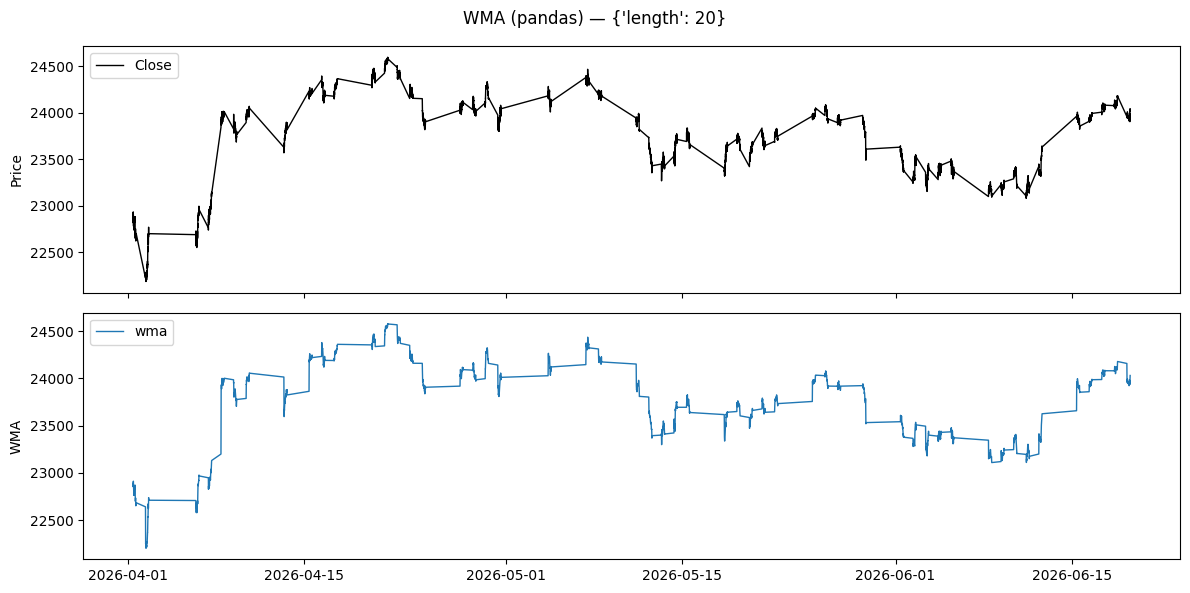

IndicatorResult(name='WMA', group='Overlap Studies', params_used={'length': 20}, outputs={'wma': array([           nan,            nan,            nan, ...,
       24029.40071429, 24030.65761905, 24031.88190476])}, warmup_bars=19, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [17]:
test_pandas_indicator("WMA")


### DEMA
Outputs: `['dema']` · Defaults: `{'length': 20}`


DEMA  |  Overlap Studies  (pandas)
Status: success  |  Warmup: 0
Outputs: ['dema']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,dema
date,,
2026-06-19 15:15:00+00:00,24016.85,24028.981681
2026-06-19 15:16:00+00:00,24018.85,24029.258355
2026-06-19 15:17:00+00:00,24027.60,24030.977734
2026-06-19 15:18:00+00:00,24025.75,24032.018969
2026-06-19 15:19:00+00:00,24028.00,24033.222619
2026-06-19 15:20:00+00:00,24031.15,24034.731979
2026-06-19 15:21:00+00:00,24030.90,24035.889690
2026-06-19 15:22:00+00:00,24027.20,24036.120926
2026-06-19 15:23:00+00:00,24031.65,24037.036556


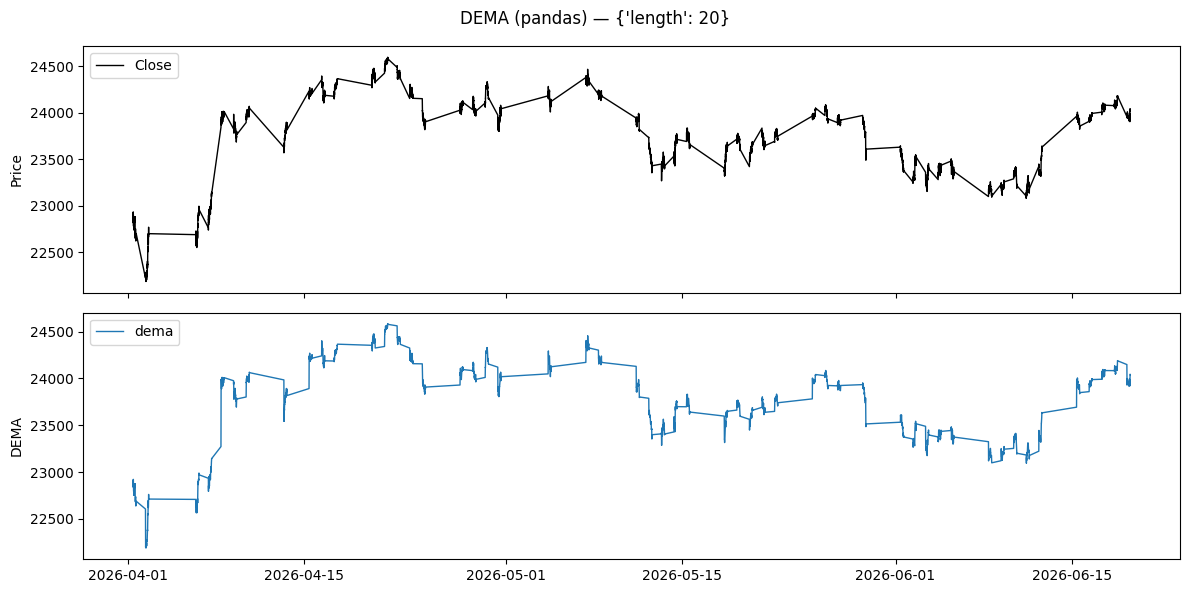

IndicatorResult(name='DEMA', group='Overlap Studies', params_used={'length': 20}, outputs={'dema': array([22843.45      , 22839.93979592, 22845.07688695, ...,
       24038.79280028, 24040.82574445, 24042.61030198])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [18]:
test_pandas_indicator("DEMA")


### TEMA
Outputs: `['tema']` · Defaults: `{'length': 20}`


TEMA  |  Overlap Studies  (pandas)
Status: success  |  Warmup: 0
Outputs: ['tema']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,tema
date,,
2026-06-19 15:15:00+00:00,24016.85,24041.743906
2026-06-19 15:16:00+00:00,24018.85,24039.813858
2026-06-19 15:17:00+00:00,24027.60,24040.206262
2026-06-19 15:18:00+00:00,24025.75,24039.771545
2026-06-19 15:19:00+00:00,24028.00,24039.739463
2026-06-19 15:20:00+00:00,24031.15,24040.287029
2026-06-19 15:21:00+00:00,24030.90,24040.440480
2026-06-19 15:22:00+00:00,24027.20,24039.388695
2026-06-19 15:23:00+00:00,24031.65,24039.480103


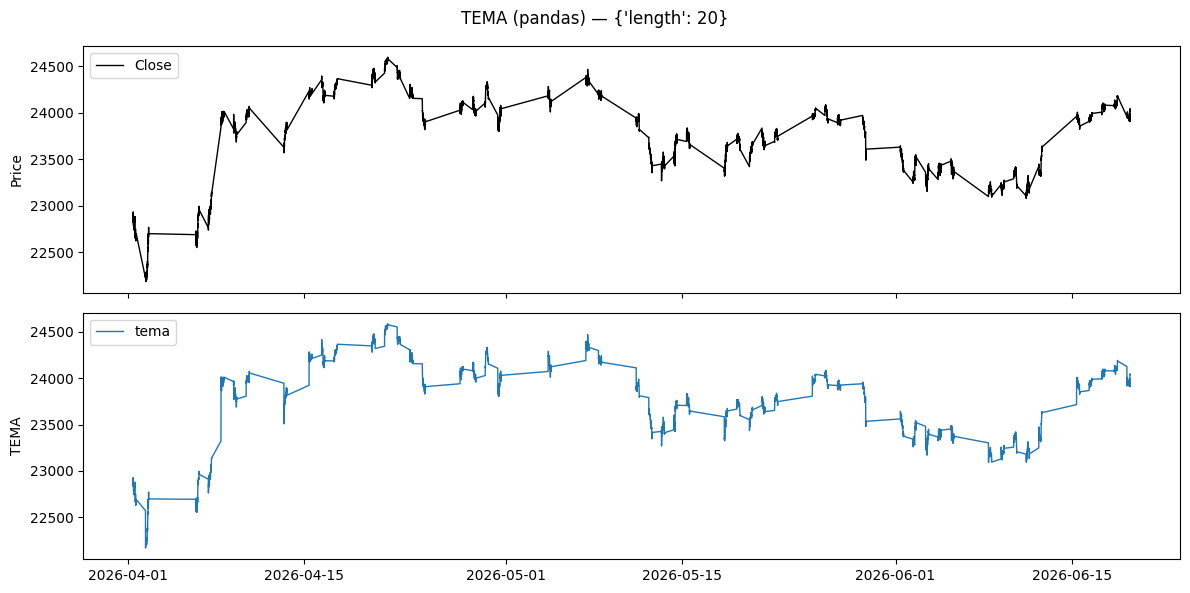

IndicatorResult(name='TEMA', group='Overlap Studies', params_used={'length': 20}, outputs={'tema': array([22843.45      , 22838.43124393, 22845.9951602 , ...,
       24038.21800614, 24040.42705029, 24042.25812136])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [19]:
test_pandas_indicator("TEMA")


### HMA
Outputs: `['hma']` · Defaults: `{'length': 20}`


HMA  |  Overlap Studies  (pandas)
Status: success  |  Warmup: 22
Outputs: ['hma']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,hma
date,,
2026-06-19 15:15:00+00:00,24016.85,24046.989398
2026-06-19 15:16:00+00:00,24018.85,24041.879455
2026-06-19 15:17:00+00:00,24027.60,24037.387275
2026-06-19 15:18:00+00:00,24025.75,24033.632597
2026-06-19 15:19:00+00:00,24028.00,24030.965537
2026-06-19 15:20:00+00:00,24031.15,24029.377613
2026-06-19 15:21:00+00:00,24030.90,24028.515245
2026-06-19 15:22:00+00:00,24027.20,24027.930861
2026-06-19 15:23:00+00:00,24031.65,24028.098935


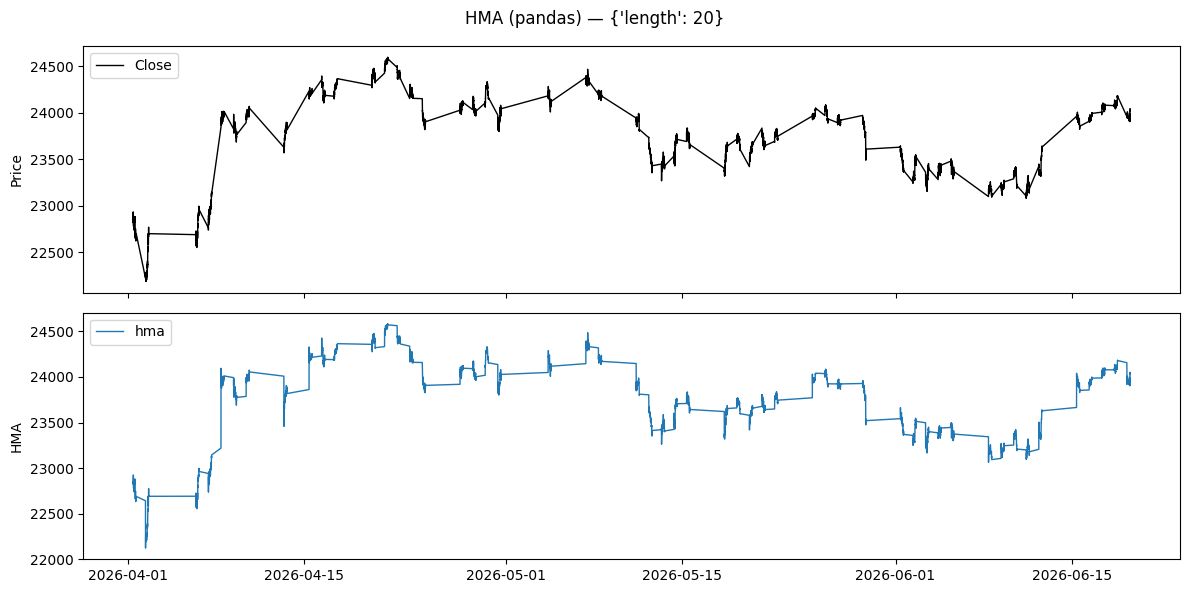

IndicatorResult(name='HMA', group='Overlap Studies', params_used={'length': 20}, outputs={'hma': array([           nan,            nan,            nan, ...,
       24031.32743723, 24033.04829004, 24035.39429004])}, warmup_bars=22, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [20]:
test_pandas_indicator("HMA")


### VWMA
Outputs: `['vwma']` · Defaults: `{'length': 20}` · requires volume


VWMA  |  Overlap Studies  (pandas)
Status: success  |  Warmup: 19
Outputs: ['vwma']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,vwma
date,,
2026-06-19 15:15:00+00:00,24016.85,24004.496688
2026-06-19 15:16:00+00:00,24018.85,24006.484430
2026-06-19 15:17:00+00:00,24027.60,24008.426999
2026-06-19 15:18:00+00:00,24025.75,24010.263809
2026-06-19 15:19:00+00:00,24028.00,24012.315113
2026-06-19 15:20:00+00:00,24031.15,24019.222181
2026-06-19 15:21:00+00:00,24030.90,24022.325768
2026-06-19 15:22:00+00:00,24027.20,24024.051354
2026-06-19 15:23:00+00:00,24031.65,24025.674504


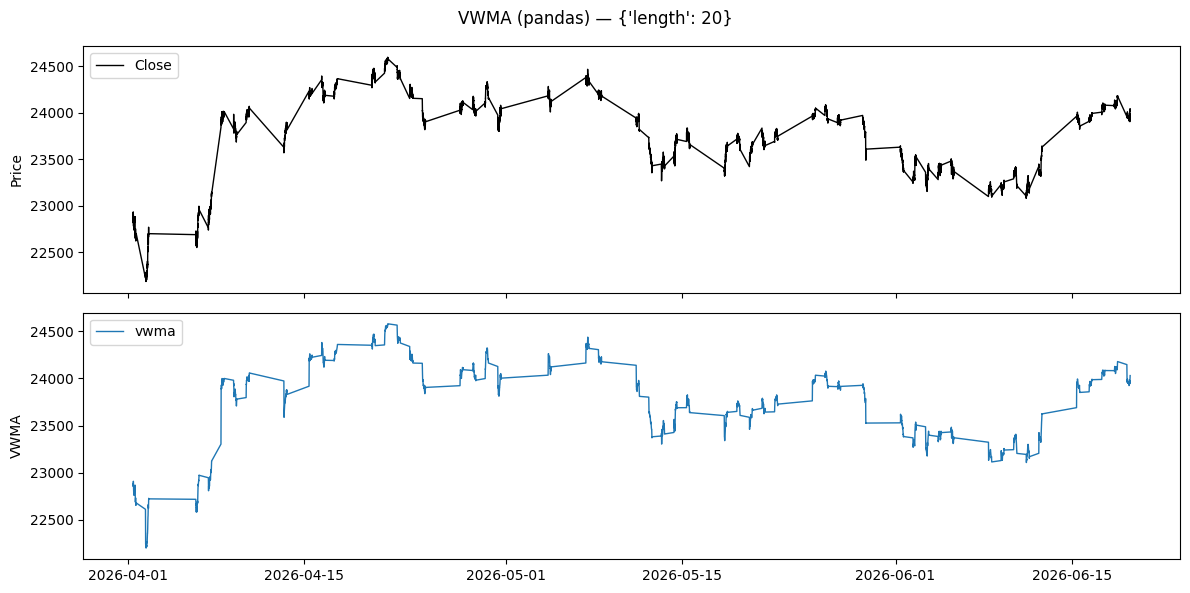

IndicatorResult(name='VWMA', group='Overlap Studies', params_used={'length': 20}, outputs={'vwma': array([           nan,            nan,            nan, ...,
       24028.83875304, 24029.56789933, 24030.24467878])}, warmup_bars=19, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [21]:
test_pandas_indicator("VWMA")


<a id="momentum-indicators"></a>
## Momentum Indicators (12)


### RSI
Outputs: `['rsi']` · Defaults: `{'length': 14}`


RSI  |  Momentum Indicators  (pandas)
Status: success  |  Warmup: 14
Outputs: ['rsi']  |  Params: {'length': 14}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,rsi
date,,
2026-06-19 15:15:00+00:00,24016.85,60.704043
2026-06-19 15:16:00+00:00,24018.85,61.531264
2026-06-19 15:17:00+00:00,24027.60,65.002425
2026-06-19 15:18:00+00:00,24025.75,63.693808
2026-06-19 15:19:00+00:00,24028.00,64.626538
2026-06-19 15:20:00+00:00,24031.15,65.945588
2026-06-19 15:21:00+00:00,24030.90,65.736080
2026-06-19 15:22:00+00:00,24027.20,62.567872
2026-06-19 15:23:00+00:00,24031.65,64.767247


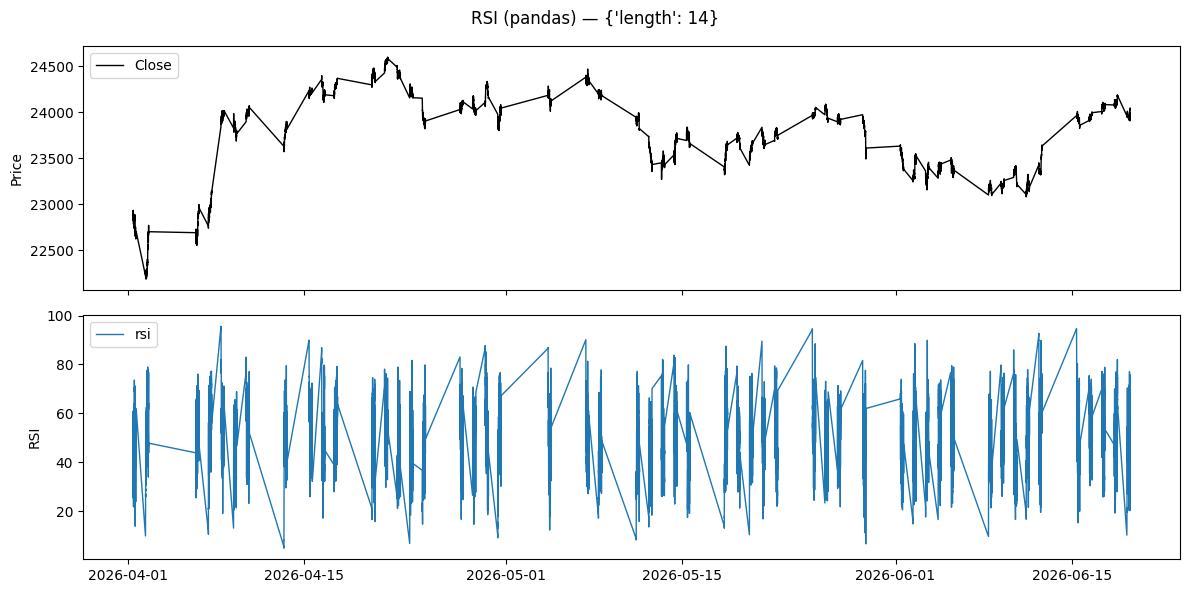

IndicatorResult(name='RSI', group='Momentum Indicators', params_used={'length': 14}, outputs={'rsi': array([        nan,         nan,         nan, ..., 64.55332519,
       67.6977514 , 67.9801147 ])}, warmup_bars=14, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [22]:
test_pandas_indicator("RSI")


### MACD
Outputs: `['macd', 'macdsignal', 'macdhist']` · Defaults: `{'fast': 12, 'slow': 26, 'signal': 9}`


MACD  |  Momentum Indicators  (pandas)
Status: success  |  Warmup: 0
Outputs: ['macd', 'macdsignal', 'macdhist']  |  Params: {'fast': 12, 'slow': 26, 'signal': 9}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,macd,macdsignal,macdhist
date,,,,
2026-06-19 15:15:00+00:00,24016.85,19.137020,16.913942,2.223078
2026-06-19 15:16:00+00:00,24018.85,17.868562,17.104866,0.763696
2026-06-19 15:17:00+00:00,24027.60,17.369131,17.157719,0.211412
2026-06-19 15:18:00+00:00,24025.75,16.632321,17.052639,-0.420318
2026-06-19 15:19:00+00:00,24028.00,16.044994,16.851110,-0.806116
2026-06-19 15:20:00+00:00,24031.15,15.653271,16.611542,-0.958272
2026-06-19 15:21:00+00:00,24030.90,15.148037,16.318841,-1.170804
2026-06-19 15:22:00+00:00,24027.20,14.284414,15.911956,-1.627541
2026-06-19 15:23:00+00:00,24031.65,13.799988,15.489562,-1.689575


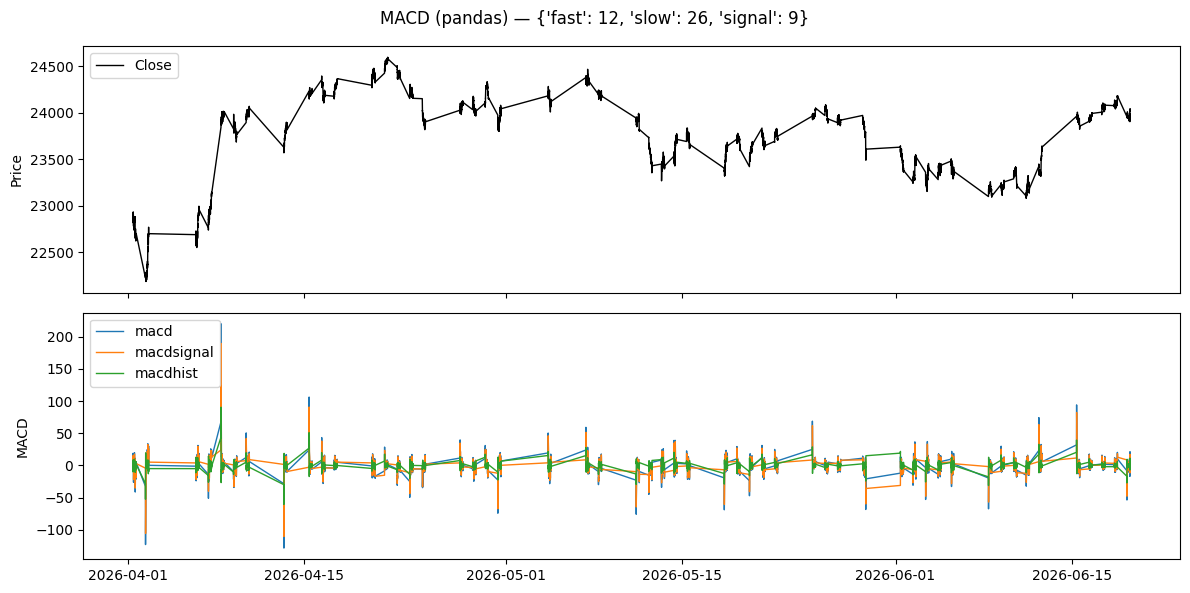

IndicatorResult(name='MACD', group='Momentum Indicators', params_used={'fast': 12, 'slow': 26, 'signal': 9}, outputs={'macd': array([ 0.        , -1.54358974,  0.85039082, ..., 11.49766218,
       11.7318906 , 11.82956939]), 'macdsignal': array([ 0.        , -0.30871795, -0.07689619, ..., 13.50465691,
       13.15010365, 12.88599679]), 'macdhist': array([ 0.        , -1.23487179,  0.92728702, ..., -2.00699473,
       -1.41821304, -1.05642741])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [23]:
test_pandas_indicator("MACD")


### ROC
Outputs: `['roc']` · Defaults: `{'length': 10}`


ROC  |  Momentum Indicators  (pandas)
Status: success  |  Warmup: 10
Outputs: ['roc']  |  Params: {'length': 10}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,roc
date,,
2026-06-19 15:15:00+00:00,24016.85,0.001874
2026-06-19 15:16:00+00:00,24018.85,-0.001665
2026-06-19 15:17:00+00:00,24027.60,0.017899
2026-06-19 15:18:00+00:00,24025.75,0.010407
2026-06-19 15:19:00+00:00,24028.00,0.022479
2026-06-19 15:20:00+00:00,24031.15,-0.009986
2026-06-19 15:21:00+00:00,24030.90,-0.024754
2026-06-19 15:22:00+00:00,24027.20,-0.044097
2026-06-19 15:23:00+00:00,24031.65,-0.007074


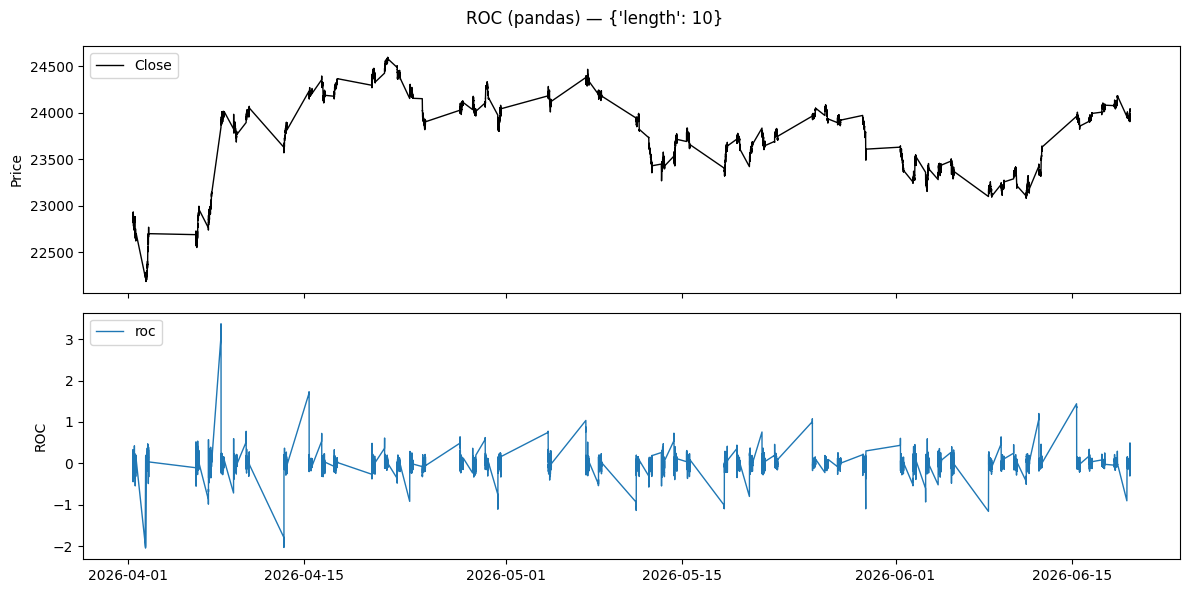

IndicatorResult(name='ROC', group='Momentum Indicators', params_used={'length': 10}, outputs={'roc': array([       nan,        nan,        nan, ..., 0.03329504, 0.06805199,
       0.06117862])}, warmup_bars=10, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [24]:
test_pandas_indicator("ROC")


### MOM
Outputs: `['mom']` · Defaults: `{'length': 10}`


MOM  |  Momentum Indicators  (pandas)
Status: success  |  Warmup: 10
Outputs: ['mom']  |  Params: {'length': 10}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,mom
date,,
2026-06-19 15:15:00+00:00,24016.85,0.45
2026-06-19 15:16:00+00:00,24018.85,-0.40
2026-06-19 15:17:00+00:00,24027.60,4.30
2026-06-19 15:18:00+00:00,24025.75,2.50
2026-06-19 15:19:00+00:00,24028.00,5.40
2026-06-19 15:20:00+00:00,24031.15,-2.40
2026-06-19 15:21:00+00:00,24030.90,-5.95
2026-06-19 15:22:00+00:00,24027.20,-10.60
2026-06-19 15:23:00+00:00,24031.65,-1.70


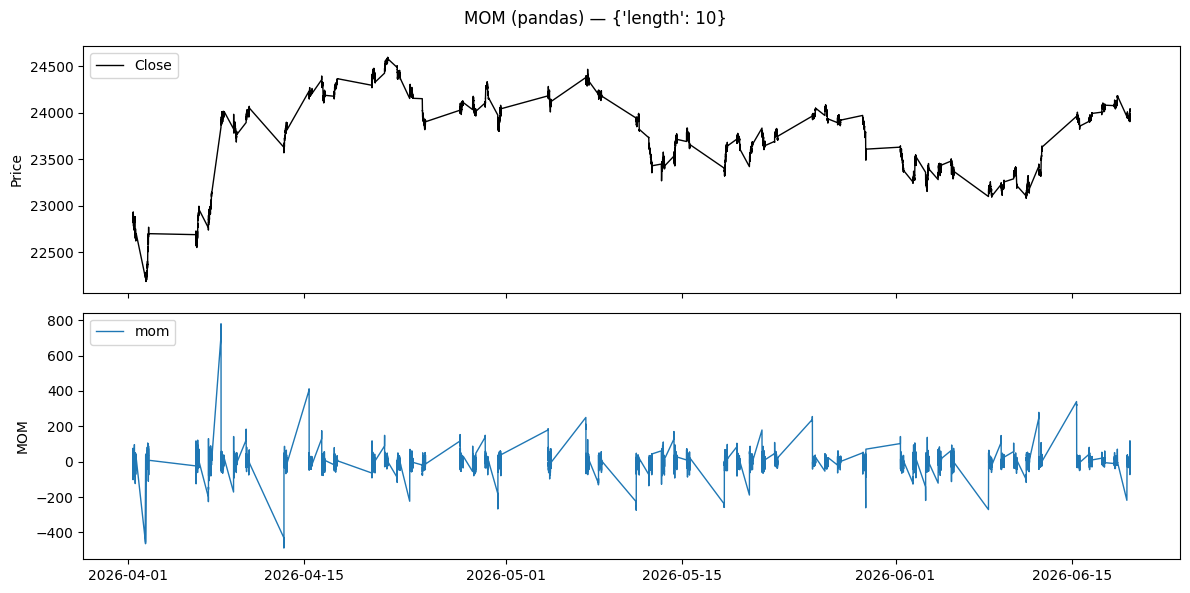

IndicatorResult(name='MOM', group='Momentum Indicators', params_used={'length': 10}, outputs={'mom': array([  nan,   nan,   nan, ...,  8.  , 16.35, 14.7 ])}, warmup_bars=10, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [25]:
test_pandas_indicator("MOM")


### STOCH
Outputs: `['slowk', 'slowd']` · Defaults: `{'k': 14, 'd': 3, 'smooth_k': 3}`


STOCH  |  Momentum Indicators  (pandas)
Status: success  |  Warmup: 17
Outputs: ['slowk', 'slowd']  |  Params: {'k': 14, 'd': 3, 'smooth_k': 3}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,slowk,slowd
date,,,
2026-06-19 15:15:00+00:00,24016.85,80.731904,88.923234
2026-06-19 15:16:00+00:00,24018.85,67.703936,79.746322
2026-06-19 15:17:00+00:00,24027.60,63.176086,70.537309
2026-06-19 15:18:00+00:00,24025.75,59.433543,63.437855
2026-06-19 15:19:00+00:00,24028.00,61.734296,61.447975
2026-06-19 15:20:00+00:00,24031.15,60.180982,60.449607
2026-06-19 15:21:00+00:00,24030.90,62.998651,61.637976
2026-06-19 15:22:00+00:00,24027.20,60.000000,61.059878
2026-06-19 15:23:00+00:00,24031.65,60.516796,61.171816


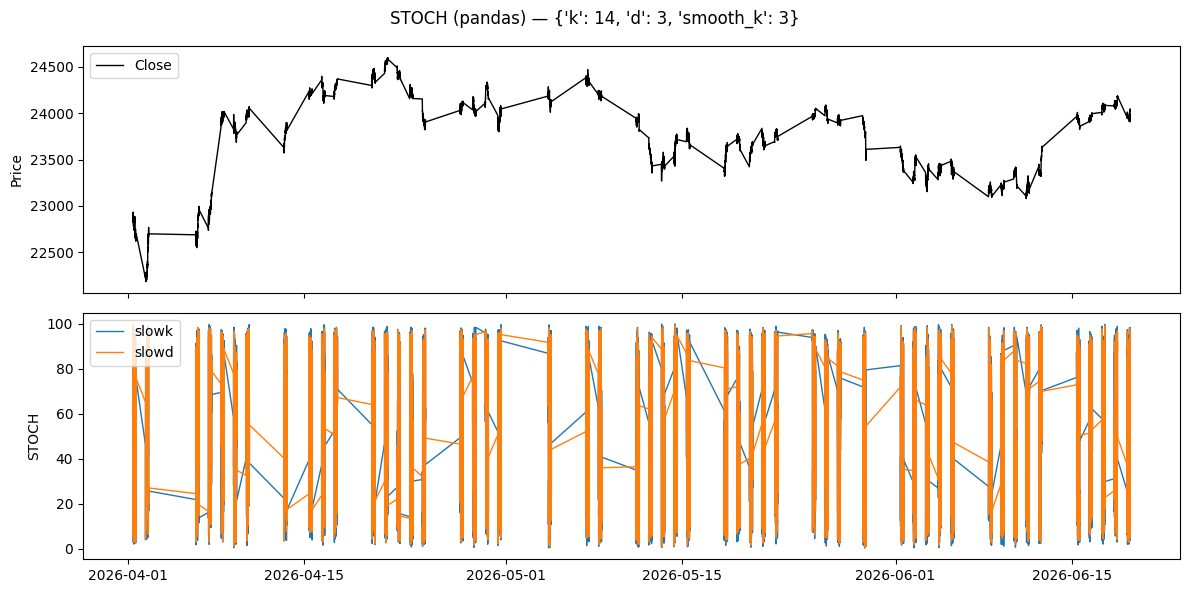

IndicatorResult(name='STOCH', group='Momentum Indicators', params_used={'k': 14, 'd': 3, 'smooth_k': 3}, outputs={'slowk': array([        nan,         nan,         nan, ..., 72.86576853,
       84.65182417, 93.09463477]), 'slowd': array([        nan,         nan,         nan, ..., 68.33157137,
       74.30491097, 83.53740916])}, warmup_bars=17, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [26]:
test_pandas_indicator("STOCH")


### STOCHRSI
Outputs: `['stochrsi_k', 'stochrsi_d']` · Defaults: `{'length': 14, 'k': 3, 'd': 3}`


STOCHRSI  |  Momentum Indicators  (pandas)
Status: success  |  Warmup: 31
Outputs: ['stochrsi_k', 'stochrsi_d']  |  Params: {'length': 14, 'k': 3, 'd': 3}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,stochrsi_k,stochrsi_d
date,,,
2026-06-19 15:15:00+00:00,24016.85,46.505916,73.772086
2026-06-19 15:16:00+00:00,24018.85,20.035857,48.793674
2026-06-19 15:17:00+00:00,24027.60,11.366043,25.969272
2026-06-19 15:18:00+00:00,24025.75,17.995859,16.465920
2026-06-19 15:19:00+00:00,24028.00,24.859639,18.073847
2026-06-19 15:20:00+00:00,24031.15,26.951107,23.268868
2026-06-19 15:21:00+00:00,24030.90,31.479850,27.763532
2026-06-19 15:22:00+00:00,24027.20,26.914751,28.448569
2026-06-19 15:23:00+00:00,24031.65,24.301776,27.565459


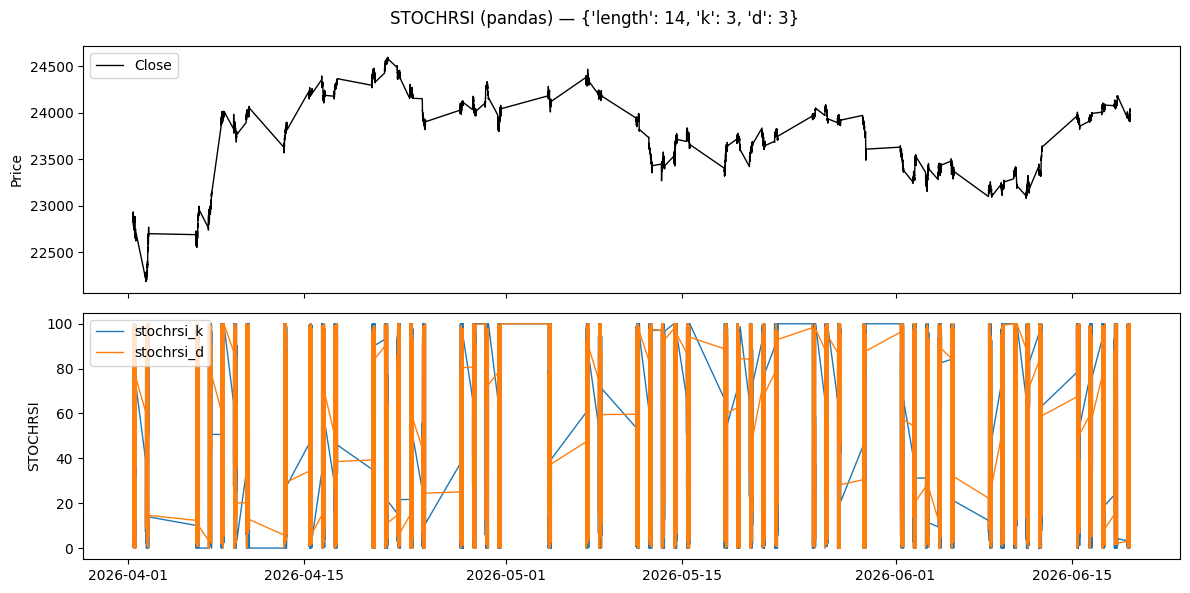

IndicatorResult(name='STOCHRSI', group='Momentum Indicators', params_used={'length': 14, 'k': 3, 'd': 3}, outputs={'stochrsi_k': array([        nan,         nan,         nan, ..., 21.32391657,
       53.49941477, 86.83274811]), 'stochrsi_d': array([        nan,         nan,         nan, ..., 18.50478018,
       29.13781942, 53.88535982])}, warmup_bars=31, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [27]:
test_pandas_indicator("STOCHRSI")


### CCI
Outputs: `['cci']` · Defaults: `{'length': 20}`


CCI  |  Momentum Indicators  (pandas)
Status: success  |  Warmup: 19
Outputs: ['cci']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,cci
date,,
2026-06-19 15:15:00+00:00,24016.85,45.633978
2026-06-19 15:16:00+00:00,24018.85,39.582152
2026-06-19 15:17:00+00:00,24027.60,48.284302
2026-06-19 15:18:00+00:00,24025.75,49.180844
2026-06-19 15:19:00+00:00,24028.00,53.727532
2026-06-19 15:20:00+00:00,24031.15,68.357383
2026-06-19 15:21:00+00:00,24030.90,71.451421
2026-06-19 15:22:00+00:00,24027.20,38.853047
2026-06-19 15:23:00+00:00,24031.65,52.294615


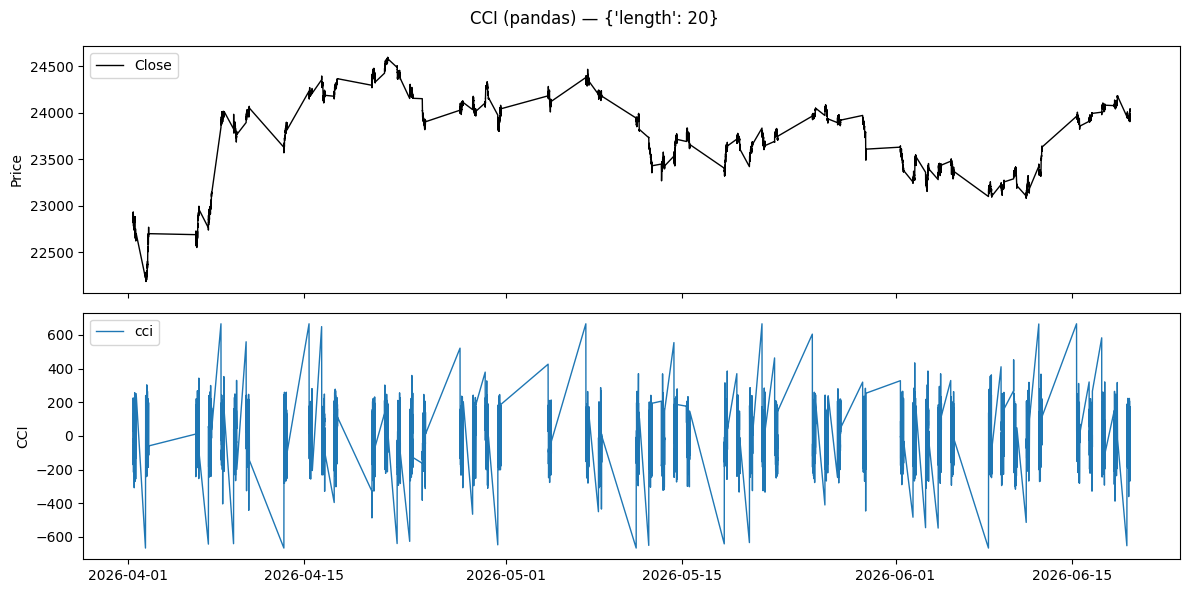

IndicatorResult(name='CCI', group='Momentum Indicators', params_used={'length': 20}, outputs={'cci': array([         nan,          nan,          nan, ...,  57.12437328,
       149.85469563, 173.0203093 ])}, warmup_bars=19, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [28]:
test_pandas_indicator("CCI")


### WILLR
Outputs: `['willr']` · Defaults: `{'length': 14}`


WILLR  |  Momentum Indicators  (pandas)
Status: success  |  Warmup: 13
Outputs: ['willr']  |  Params: {'length': 14}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,willr
date,,
2026-06-19 15:15:00+00:00,24016.85,-33.659491
2026-06-19 15:16:00+00:00,24018.85,-45.813282
2026-06-19 15:17:00+00:00,24027.60,-30.998970
2026-06-19 15:18:00+00:00,24025.75,-44.887118
2026-06-19 15:19:00+00:00,24028.00,-38.911023
2026-06-19 15:20:00+00:00,24031.15,-35.658915
2026-06-19 15:21:00+00:00,24030.90,-36.434109
2026-06-19 15:22:00+00:00,24027.20,-47.906977
2026-06-19 15:23:00+00:00,24031.65,-34.108527


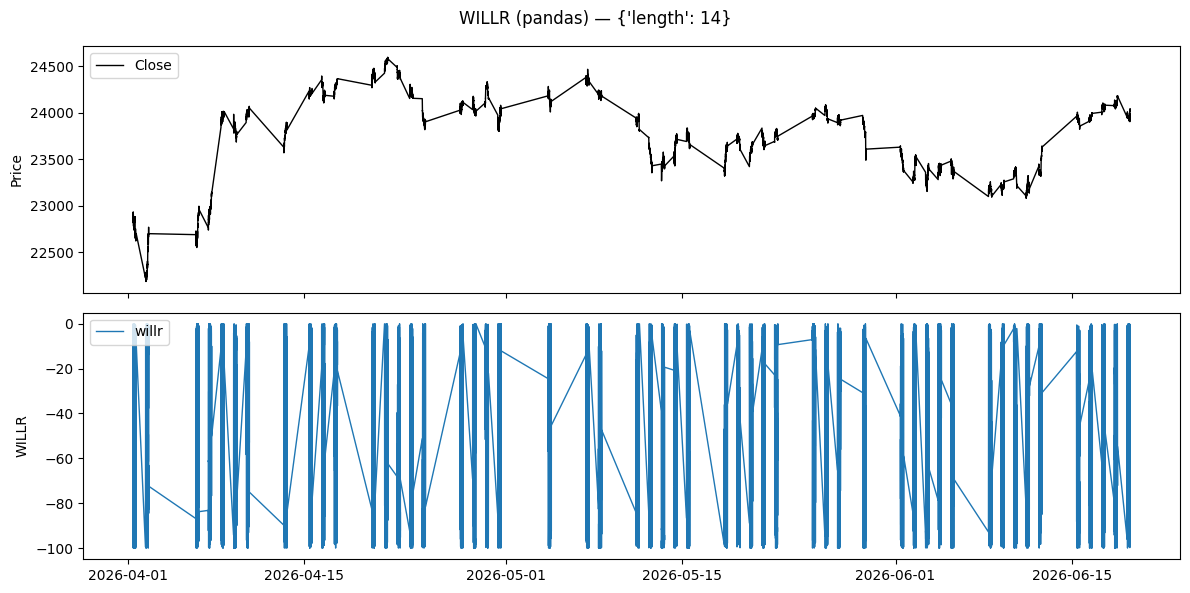

IndicatorResult(name='WILLR', group='Momentum Indicators', params_used={'length': 14}, outputs={'willr': array([         nan,          nan,          nan, ...,  -4.72589792,
        -3.20610687, -12.78409091])}, warmup_bars=13, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [29]:
test_pandas_indicator("WILLR")


### MFI
Outputs: `['mfi']` · Defaults: `{'length': 14}` · requires volume


MFI  |  Momentum Indicators  (pandas)
Status: success  |  Warmup: 13
Outputs: ['mfi']  |  Params: {'length': 14}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,mfi
date,,
2026-06-19 15:15:00+00:00,24016.85,65.679236
2026-06-19 15:16:00+00:00,24018.85,58.842048
2026-06-19 15:17:00+00:00,24027.60,58.602319
2026-06-19 15:18:00+00:00,24025.75,58.457707
2026-06-19 15:19:00+00:00,24028.00,57.947609
2026-06-19 15:20:00+00:00,24031.15,58.208049
2026-06-19 15:21:00+00:00,24030.90,57.912815
2026-06-19 15:22:00+00:00,24027.20,51.254119
2026-06-19 15:23:00+00:00,24031.65,58.476101


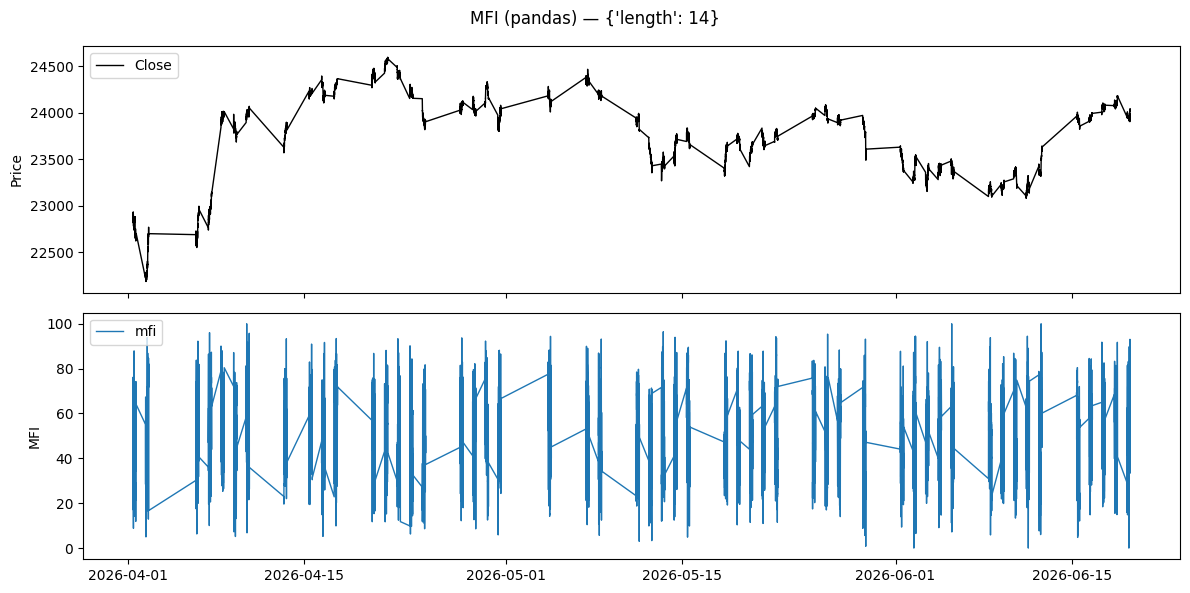

IndicatorResult(name='MFI', group='Momentum Indicators', params_used={'length': 14}, outputs={'mfi': array([        nan,         nan,         nan, ..., 57.49793838,
       63.77187469, 70.52477577])}, warmup_bars=13, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [30]:
test_pandas_indicator("MFI")


### CMO
Outputs: `['cmo']` · Defaults: `{'length': 14}`


CMO  |  Momentum Indicators  (pandas)
Status: success  |  Warmup: 14
Outputs: ['cmo']  |  Params: {'length': 14}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,cmo
date,,
2026-06-19 15:15:00+00:00,24016.85,53.565684
2026-06-19 15:16:00+00:00,24018.85,36.742148
2026-06-19 15:17:00+00:00,24027.60,40.399174
2026-06-19 15:18:00+00:00,24025.75,28.571429
2026-06-19 15:19:00+00:00,24028.00,19.795222
2026-06-19 15:20:00+00:00,24031.15,20.203735
2026-06-19 15:21:00+00:00,24030.90,13.793103
2026-06-19 15:22:00+00:00,24027.20,6.723404
2026-06-19 15:23:00+00:00,24031.65,14.468425


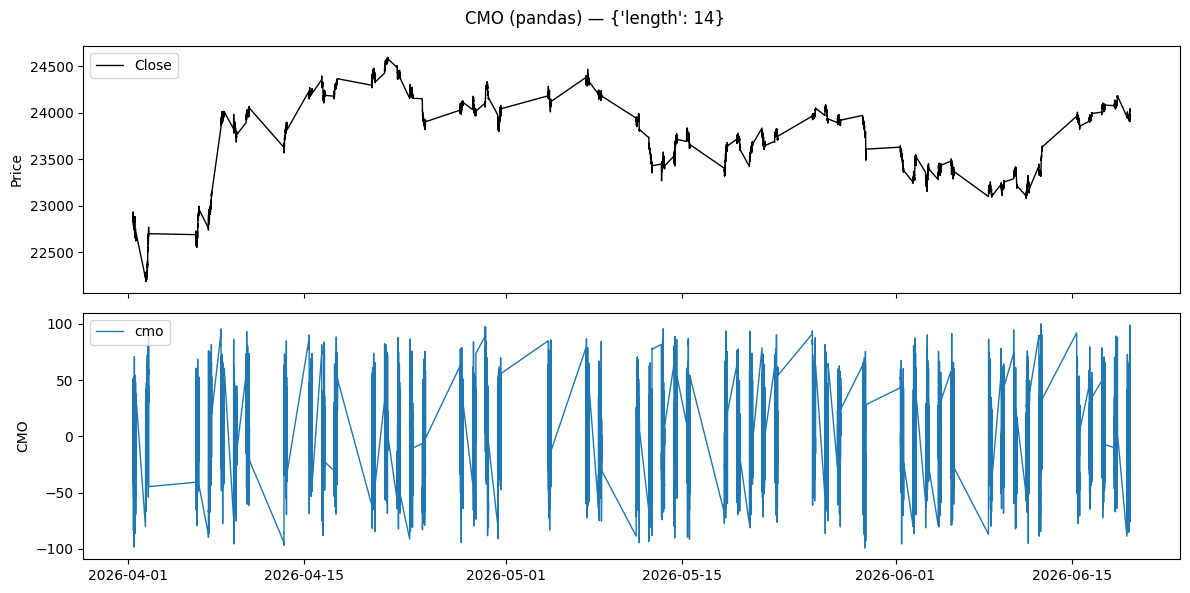

IndicatorResult(name='CMO', group='Momentum Indicators', params_used={'length': 14}, outputs={'cmo': array([        nan,         nan,         nan, ...,  3.76569038,
       25.31328321, 51.34061569])}, warmup_bars=14, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [31]:
test_pandas_indicator("CMO")


### PPO
Outputs: `['ppo']` · Defaults: `{'fast': 12, 'slow': 26}`


PPO  |  Momentum Indicators  (pandas)
Status: success  |  Warmup: 0
Outputs: ['ppo']  |  Params: {'fast': 12, 'slow': 26}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,ppo
date,,
2026-06-19 15:15:00+00:00,24016.85,0.079745
2026-06-19 15:16:00+00:00,24018.85,0.074454
2026-06-19 15:17:00+00:00,24027.60,0.072367
2026-06-19 15:18:00+00:00,24025.75,0.069292
2026-06-19 15:19:00+00:00,24028.00,0.066840
2026-06-19 15:20:00+00:00,24031.15,0.065203
2026-06-19 15:21:00+00:00,24030.90,0.063094
2026-06-19 15:22:00+00:00,24027.20,0.059493
2026-06-19 15:23:00+00:00,24031.65,0.057472


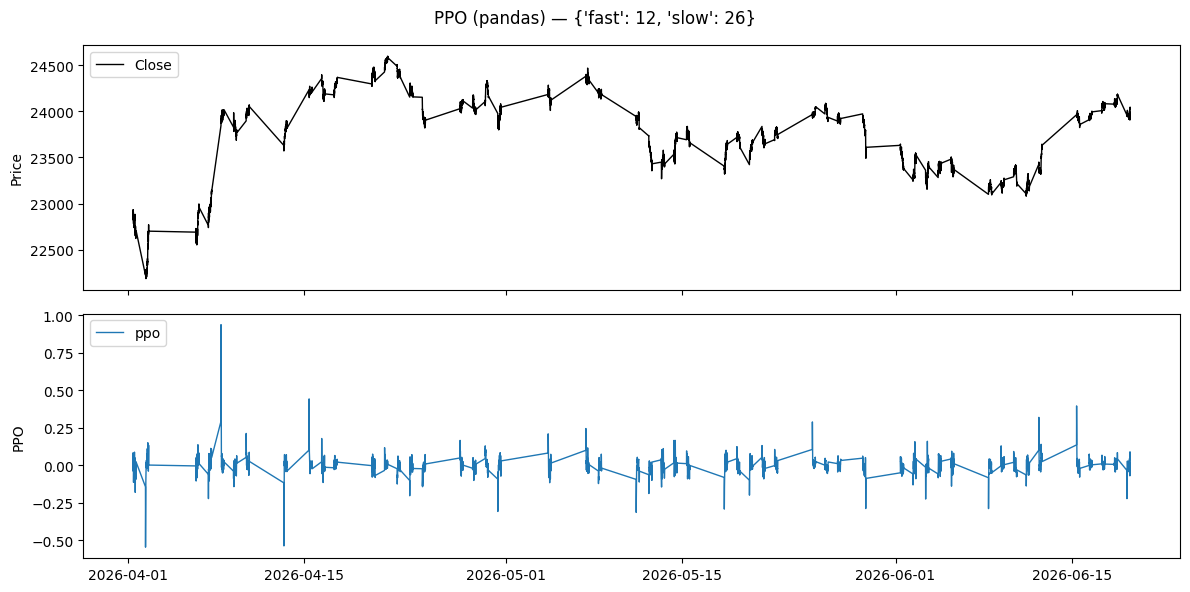

IndicatorResult(name='PPO', group='Momentum Indicators', params_used={'fast': 12, 'slow': 26}, outputs={'ppo': array([ 0.        , -0.00675768,  0.0037226 , ...,  0.04787304,
        0.04884451,  0.04924757])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [32]:
test_pandas_indicator("PPO")


### TRIX
Outputs: `['trix']` · Defaults: `{'length': 15}`


TRIX  |  Momentum Indicators  (pandas)
Status: success  |  Warmup: 1
Outputs: ['trix']  |  Params: {'length': 15}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,trix
date,,
2026-06-19 15:15:00+00:00,24016.85,0.010072
2026-06-19 15:16:00+00:00,24018.85,0.010375
2026-06-19 15:17:00+00:00,24027.60,0.010567
2026-06-19 15:18:00+00:00,24025.75,0.010639
2026-06-19 15:19:00+00:00,24028.00,0.010626
2026-06-19 15:20:00+00:00,24031.15,0.010561
2026-06-19 15:21:00+00:00,24030.90,0.010442
2026-06-19 15:22:00+00:00,24027.20,0.010241
2026-06-19 15:23:00+00:00,24031.65,0.010010


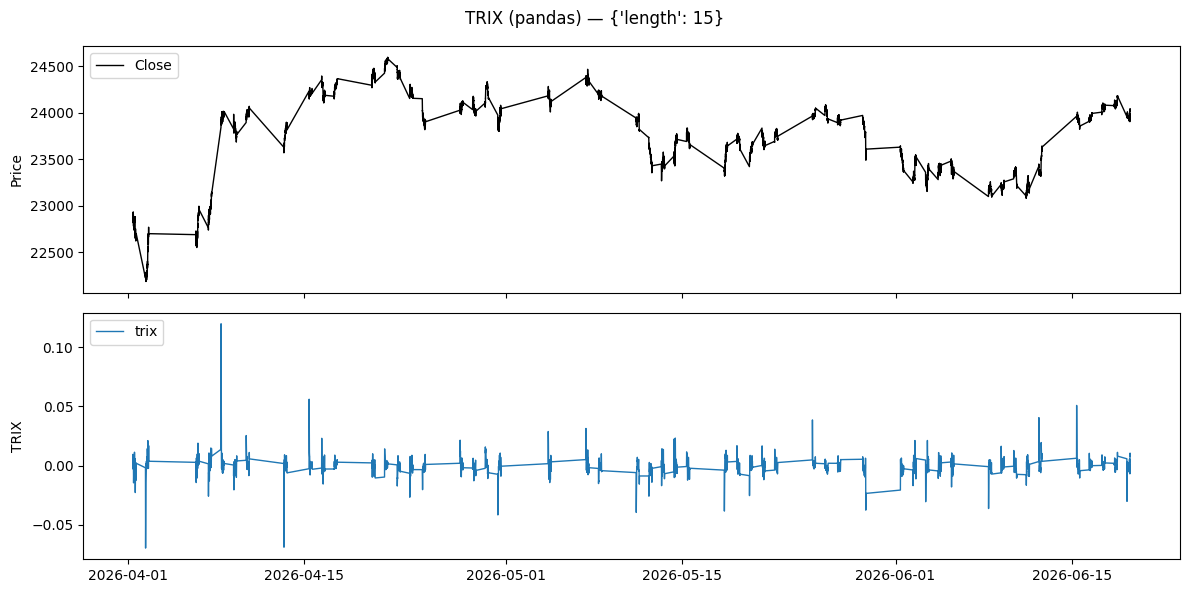

IndicatorResult(name='TRIX', group='Momentum Indicators', params_used={'length': 15}, outputs={'trix': array([            nan, -1.65443349e-04, -4.99644016e-05, ...,
        8.78159503e-03,  8.52033420e-03,  8.30393714e-03])}, warmup_bars=1, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [ ]:
test_pandas_indicator("TRIX")

<a id="volatility-indicators"></a>
## Volatility Indicators (5)


### BBANDS
Outputs: `['upperband', 'middleband', 'lowerband']` · Defaults: `{'length': 20, 'std': 2.0}`


BBANDS  |  Volatility Indicators  (pandas)
Status: success  |  Warmup: 19
Outputs: ['upperband', 'middleband', 'lowerband']  |  Params: {'length': 20, 'std': 2.0}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,upperband,middleband,lowerband
date,,,,
2026-06-19 15:15:00+00:00,24016.85,24088.094466,23992.2750,23896.455534
2026-06-19 15:16:00+00:00,24018.85,24085.818956,23997.7500,23909.681044
2026-06-19 15:17:00+00:00,24027.60,24082.383906,24003.5900,23924.796094
2026-06-19 15:18:00+00:00,24025.75,24073.694110,24009.6375,23945.580890
2026-06-19 15:19:00+00:00,24028.00,24059.804607,24015.5100,23971.215393
2026-06-19 15:20:00+00:00,24031.15,24053.360713,24019.3650,23985.369287
2026-06-19 15:21:00+00:00,24030.90,24046.252863,24022.5650,23998.877137
2026-06-19 15:22:00+00:00,24027.20,24043.692928,24024.2400,24004.787072
2026-06-19 15:23:00+00:00,24031.65,24041.273169,24025.9100,24010.546831


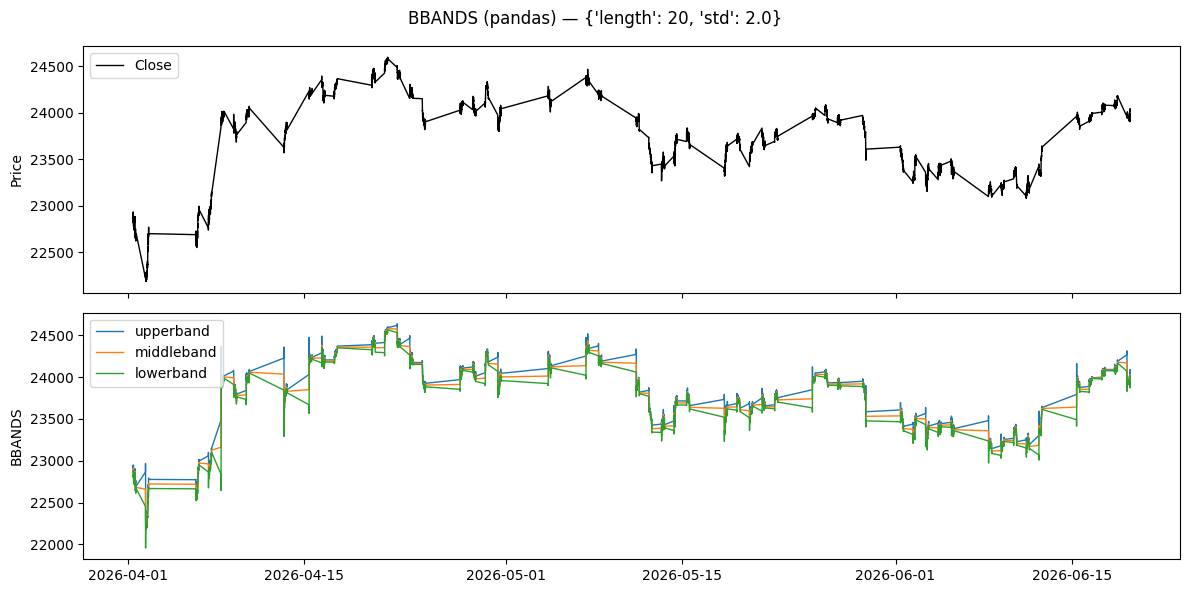

IndicatorResult(name='BBANDS', group='Volatility Indicators', params_used={'length': 20, 'std': 2.0}, outputs={'upperband': array([           nan,            nan,            nan, ...,
       24040.22920229, 24042.27462931, 24044.04022766]), 'middleband': array([       nan,        nan,        nan, ..., 24028.9025, 24029.845 ,
       24030.85  ]), 'lowerband': array([           nan,            nan,            nan, ...,
       24017.57579771, 24017.41537069, 24017.65977234])}, warmup_bars=19, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [34]:
test_pandas_indicator("BBANDS")


### ATR
Outputs: `['atr']` · Defaults: `{'length': 14}`


ATR  |  Volatility Indicators  (pandas)
Status: success  |  Warmup: 13
Outputs: ['atr']  |  Params: {'length': 14}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,atr
date,,
2026-06-19 15:15:00+00:00,24016.85,13.135714
2026-06-19 15:16:00+00:00,24018.85,11.700000
2026-06-19 15:17:00+00:00,24027.60,11.532143
2026-06-19 15:18:00+00:00,24025.75,10.896429
2026-06-19 15:19:00+00:00,24028.00,10.139286
2026-06-19 15:20:00+00:00,24031.15,9.732143
2026-06-19 15:21:00+00:00,24030.90,9.567857
2026-06-19 15:22:00+00:00,24027.20,9.535714
2026-06-19 15:23:00+00:00,24031.65,9.332143


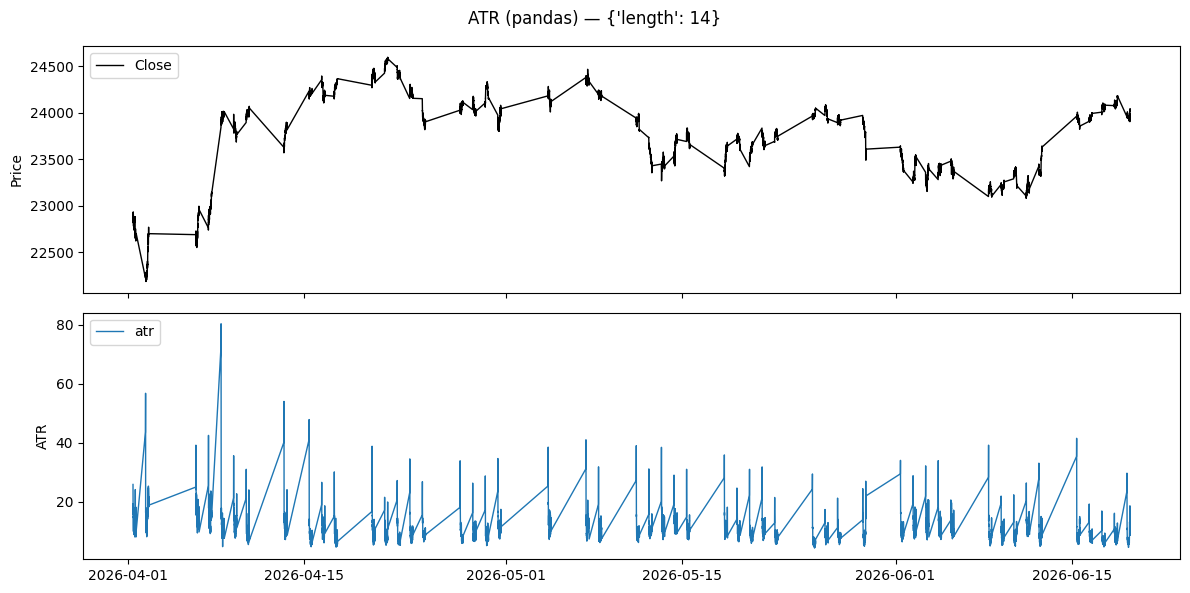

IndicatorResult(name='ATR', group='Volatility Indicators', params_used={'length': 14}, outputs={'atr': array([       nan,        nan,        nan, ..., 9.06428571, 9.17857143,
       8.85357143])}, warmup_bars=13, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [35]:
test_pandas_indicator("ATR")


### NATR
Outputs: `['natr']` · Defaults: `{'length': 14}`


NATR  |  Volatility Indicators  (pandas)
Status: success  |  Warmup: 13
Outputs: ['natr']  |  Params: {'length': 14}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,natr
date,,
2026-06-19 15:15:00+00:00,24016.85,0.054694
2026-06-19 15:16:00+00:00,24018.85,0.048712
2026-06-19 15:17:00+00:00,24027.60,0.047995
2026-06-19 15:18:00+00:00,24025.75,0.045353
2026-06-19 15:19:00+00:00,24028.00,0.042198
2026-06-19 15:20:00+00:00,24031.15,0.040498
2026-06-19 15:21:00+00:00,24030.90,0.039815
2026-06-19 15:22:00+00:00,24027.20,0.039687
2026-06-19 15:23:00+00:00,24031.65,0.038833


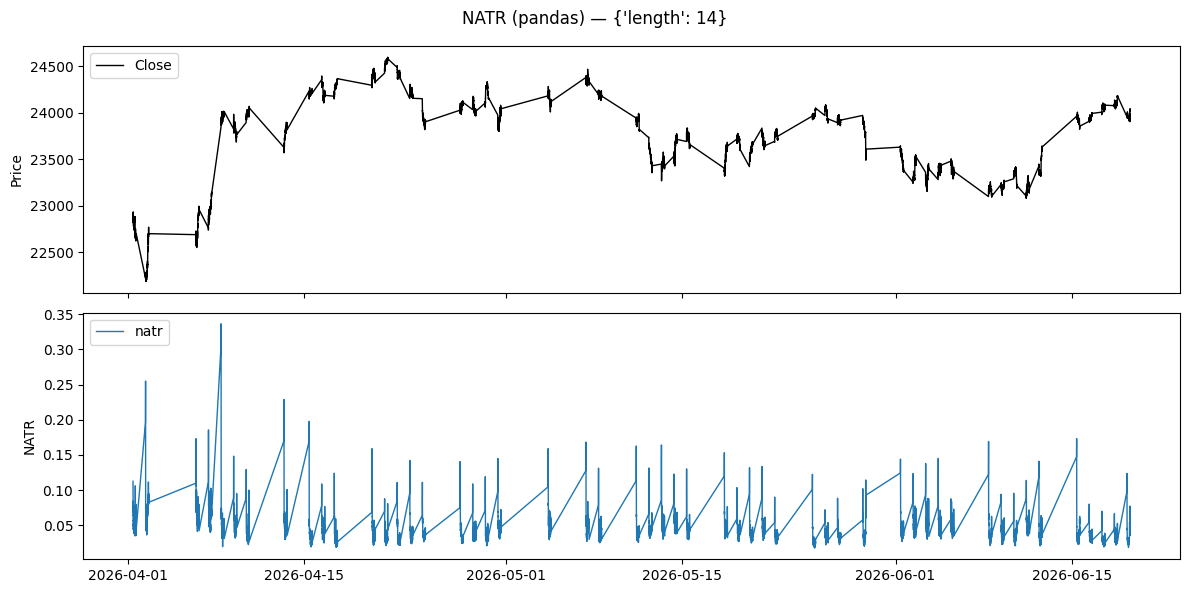

IndicatorResult(name='NATR', group='Volatility Indicators', params_used={'length': 14}, outputs={'natr': array([       nan,        nan,        nan, ..., 0.03771192, 0.03817708,
       0.03682436])}, warmup_bars=13, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [36]:
test_pandas_indicator("NATR")


### TRANGE
Outputs: `['trange']` · Defaults: `{}`


TRANGE  |  Volatility Indicators  (pandas)
Status: success  |  Warmup: 0
Outputs: ['trange']  |  Params: {}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,trange
date,,
2026-06-19 15:15:00+00:00,24016.85,16.85
2026-06-19 15:16:00+00:00,24018.85,8.00
2026-06-19 15:17:00+00:00,24027.60,12.55
2026-06-19 15:18:00+00:00,24025.75,6.10
2026-06-19 15:19:00+00:00,24028.00,4.70
2026-06-19 15:20:00+00:00,24031.15,8.70
2026-06-19 15:21:00+00:00,24030.90,5.85
2026-06-19 15:22:00+00:00,24027.20,8.30
2026-06-19 15:23:00+00:00,24031.65,8.45


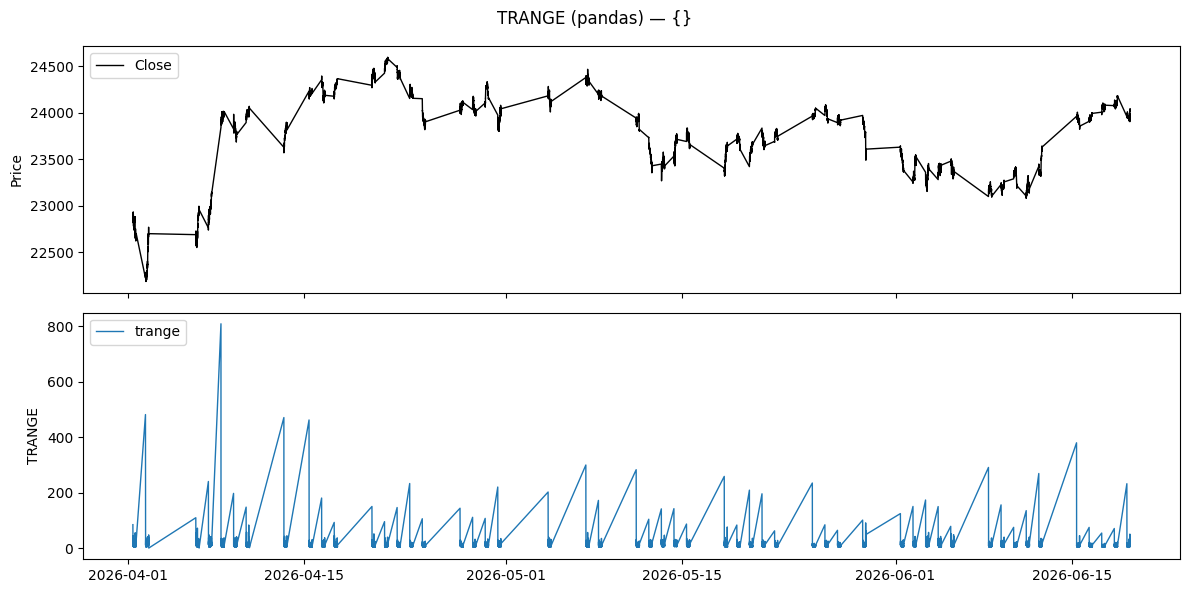

IndicatorResult(name='TRANGE', group='Volatility Indicators', params_used={}, outputs={'trange': array([84.4 , 42.3 , 52.45, ..., 13.75, 12.  , 12.3 ])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [37]:
test_pandas_indicator("TRANGE")


### DONCHIAN
Outputs: `['donchian_upper', 'donchian_mid', 'donchian_lower']` · Defaults: `{'length': 20}`


DONCHIAN  |  Volatility Indicators  (pandas)
Status: success  |  Warmup: 19
Outputs: ['donchian_upper', 'donchian_mid', 'donchian_lower']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,donchian_upper,donchian_mid,donchian_lower
date,,,,
2026-06-19 15:15:00+00:00,24016.85,24042.65,23972.275,23901.90
2026-06-19 15:16:00+00:00,24018.85,24042.65,23972.275,23901.90
2026-06-19 15:17:00+00:00,24027.60,24042.65,23972.275,23901.90
2026-06-19 15:18:00+00:00,24025.75,24042.65,23972.275,23901.90
2026-06-19 15:19:00+00:00,24028.00,24042.65,23973.550,23904.45
2026-06-19 15:20:00+00:00,24031.15,24042.65,23997.575,23952.50
2026-06-19 15:21:00+00:00,24030.90,24042.65,24004.325,23966.00
2026-06-19 15:22:00+00:00,24027.20,24042.65,24016.675,23990.70
2026-06-19 15:23:00+00:00,24031.65,24042.65,24018.375,23994.10


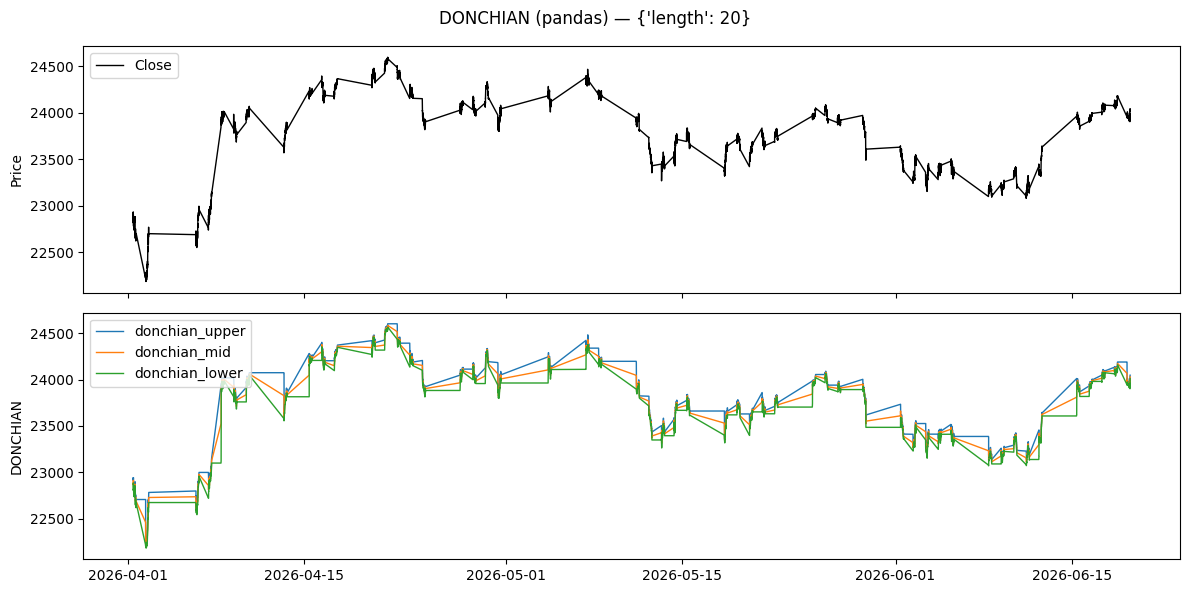

IndicatorResult(name='DONCHIAN', group='Volatility Indicators', params_used={'length': 20}, outputs={'donchian_upper': array([     nan,      nan,      nan, ..., 24042.65, 24043.15, 24047.2 ]), 'donchian_mid': array([      nan,       nan,       nan, ..., 24026.525, 24026.775,
       24028.8  ]), 'donchian_lower': array([    nan,     nan,     nan, ..., 24010.4, 24010.4, 24010.4])}, warmup_bars=19, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [38]:
test_pandas_indicator("DONCHIAN")


<a id="volume-indicators"></a>
## Volume Indicators (5)


### OBV
Outputs: `['obv']` · Defaults: `{}` · requires volume


OBV  |  Volume Indicators  (pandas)
Status: success  |  Warmup: 0
Outputs: ['obv']  |  Params: {}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,obv
date,,
2026-06-19 15:15:00+00:00,24016.85,-835709.0
2026-06-19 15:16:00+00:00,24018.85,4458342.0
2026-06-19 15:17:00+00:00,24027.60,9625808.0
2026-06-19 15:18:00+00:00,24025.75,3912516.0
2026-06-19 15:19:00+00:00,24028.00,8997180.0
2026-06-19 15:20:00+00:00,24031.15,15709041.0
2026-06-19 15:21:00+00:00,24030.90,10540686.0
2026-06-19 15:22:00+00:00,24027.20,5874366.0
2026-06-19 15:23:00+00:00,24031.65,10868590.0


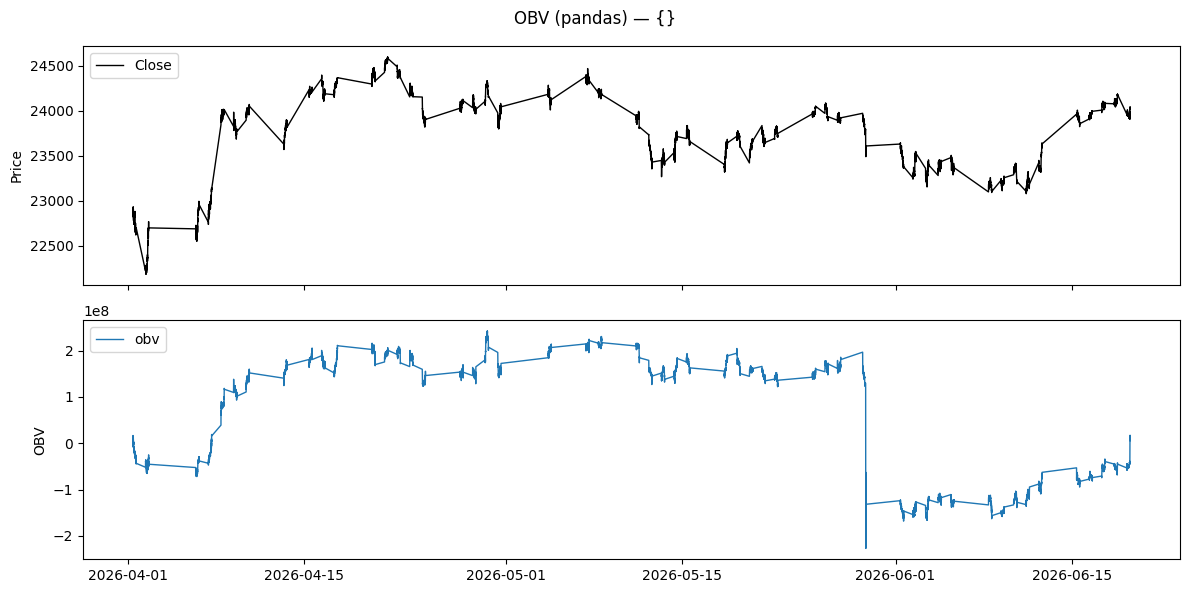

IndicatorResult(name='OBV', group='Volume Indicators', params_used={}, outputs={'obv': array([       0., -8022698., -1695568., ..., 11240874., 14702483.,
       16851326.])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [39]:
test_pandas_indicator("OBV")


### AD
Outputs: `['ad']` · Defaults: `{}` · requires volume


AD  |  Volume Indicators  (pandas)
Status: success  |  Warmup: 0
Outputs: ['ad']  |  Params: {}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,ad
date,,
2026-06-19 15:15:00+00:00,24016.85,-3.980691e+08
2026-06-19 15:16:00+00:00,24018.85,-3.942971e+08
2026-06-19 15:17:00+00:00,24027.60,-3.891296e+08
2026-06-19 15:18:00+00:00,24025.75,-3.877247e+08
2026-06-19 15:19:00+00:00,24028.00,-3.855610e+08
2026-06-19 15:20:00+00:00,24031.15,-3.847895e+08
2026-06-19 15:21:00+00:00,24030.90,-3.863356e+08
2026-06-19 15:22:00+00:00,24027.20,-3.872352e+08
2026-06-19 15:23:00+00:00,24031.65,-3.843686e+08


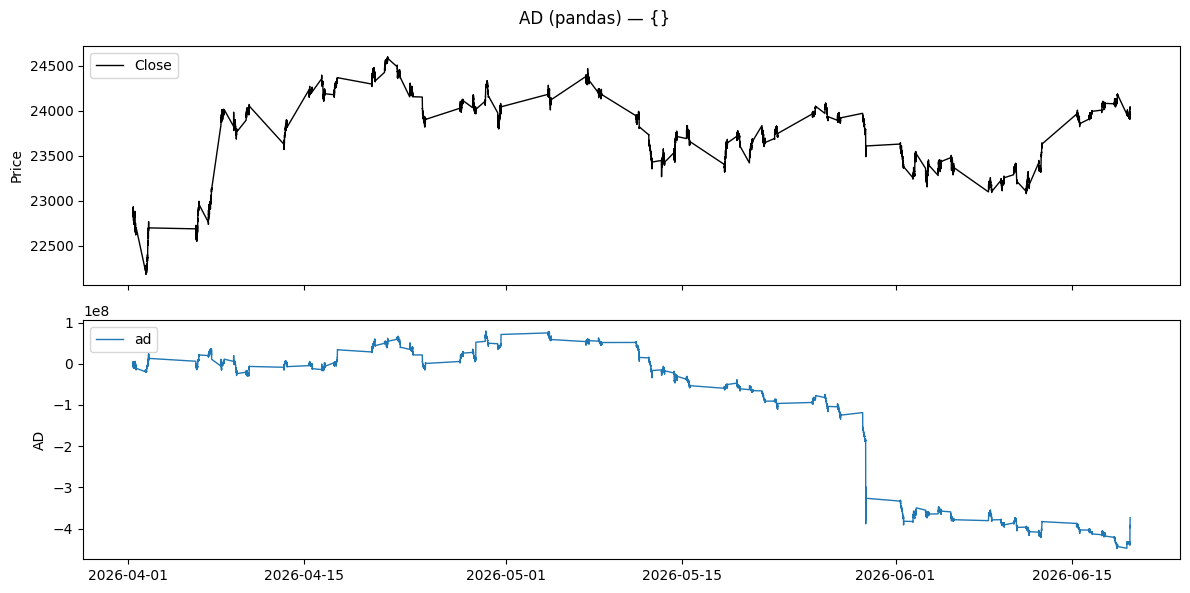

IndicatorResult(name='AD', group='Volume Indicators', params_used={}, outputs={'ad': array([-5.69392037e+06, -7.98882925e+06, -3.24197386e+06, ...,
       -3.77126893e+08, -3.74271065e+08, -3.73694546e+08])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [40]:
test_pandas_indicator("AD")


### ADOSC
Outputs: `['adosc']` · Defaults: `{'fast': 3, 'slow': 10}` · requires volume


ADOSC  |  Volume Indicators  (pandas)
Status: success  |  Warmup: 0
Outputs: ['adosc']  |  Params: {'fast': 3, 'slow': 10}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,adosc
date,,
2026-06-19 15:15:00+00:00,24016.85,3.307963e+06
2026-06-19 15:16:00+00:00,24018.85,3.439701e+06
2026-06-19 15:17:00+00:00,24027.60,4.825087e+06
2026-06-19 15:18:00+00:00,24025.75,5.400208e+06
2026-06-19 15:19:00+00:00,24028.00,5.833002e+06
2026-06-19 15:20:00+00:00,24031.15,5.725252e+06
2026-06-19 15:21:00+00:00,24030.90,4.668757e+06
2026-06-19 15:22:00+00:00,24027.20,3.525908e+06
2026-06-19 15:23:00+00:00,24031.65,3.649912e+06


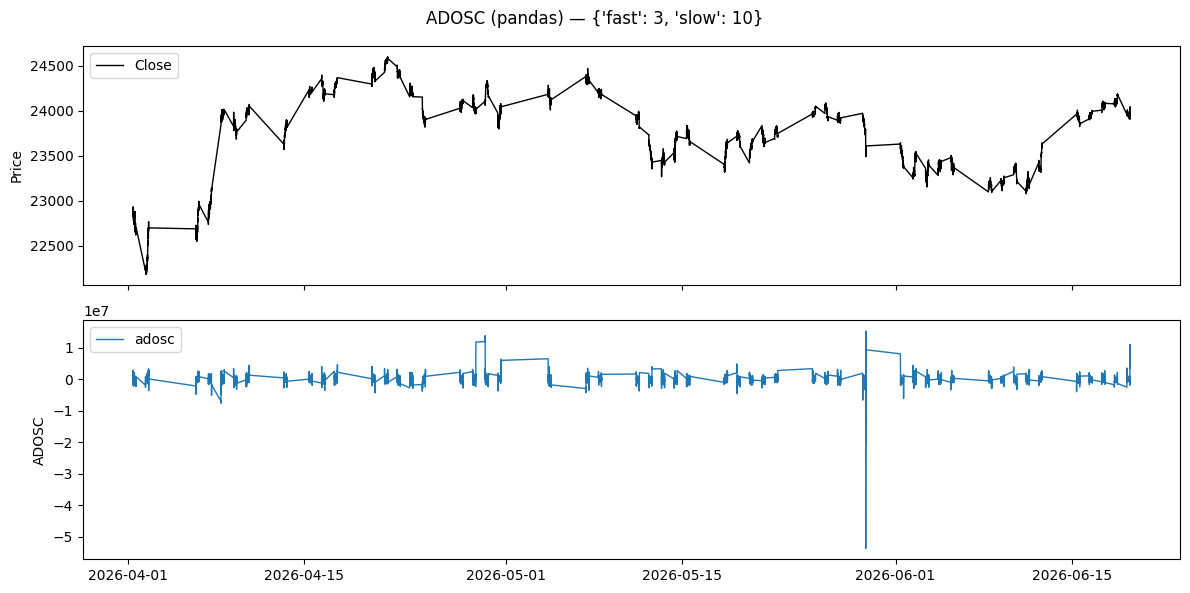

IndicatorResult(name='ADOSC', group='Volume Indicators', params_used={'fast': 3, 'slow': 10}, outputs={'adosc': array([      0.        , -730198.28132402,  547828.982314  , ...,
       4490290.41798216, 5355796.87877512, 5406414.89537489])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [41]:
test_pandas_indicator("ADOSC")


### CMF
Outputs: `['cmf']` · Defaults: `{'length': 20}` · requires volume


CMF  |  Volume Indicators  (pandas)
Status: success  |  Warmup: 19
Outputs: ['cmf']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,cmf
date,,
2026-06-19 15:15:00+00:00,24016.85,0.401986
2026-06-19 15:16:00+00:00,24018.85,0.419924
2026-06-19 15:17:00+00:00,24027.60,0.450642
2026-06-19 15:18:00+00:00,24025.75,0.450372
2026-06-19 15:19:00+00:00,24028.00,0.449822
2026-06-19 15:20:00+00:00,24031.15,0.378655
2026-06-19 15:21:00+00:00,24030.90,0.323398
2026-06-19 15:22:00+00:00,24027.20,0.267679
2026-06-19 15:23:00+00:00,24031.65,0.293893


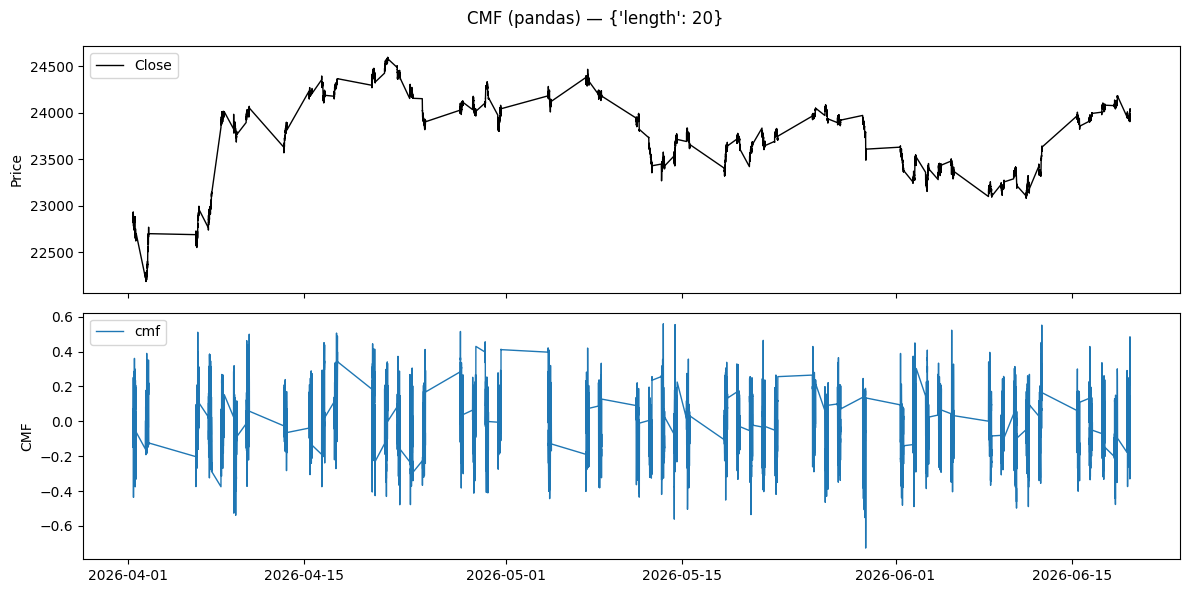

IndicatorResult(name='CMF', group='Volume Indicators', params_used={'length': 20}, outputs={'cmf': array([       nan,        nan,        nan, ..., 0.22282943, 0.23390101,
       0.23586398])}, warmup_bars=19, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [42]:
test_pandas_indicator("CMF")


### VWAP
Outputs: `['vwap']` · Defaults: `{}` · requires volume


VWAP  |  Volume Indicators  (pandas)
Status: success  |  Warmup: 0
Outputs: ['vwap']  |  Params: {}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,real
date,,
2026-06-19 15:15:00+00:00,24016.85,23752.320188
2026-06-19 15:16:00+00:00,24018.85,23752.381475
2026-06-19 15:17:00+00:00,24027.60,23752.442730
2026-06-19 15:18:00+00:00,24025.75,23752.510881
2026-06-19 15:19:00+00:00,24028.00,23752.571968
2026-06-19 15:20:00+00:00,24031.15,23752.653584
2026-06-19 15:21:00+00:00,24030.90,23752.716549
2026-06-19 15:22:00+00:00,24027.20,23752.772609
2026-06-19 15:23:00+00:00,24031.65,23752.833085


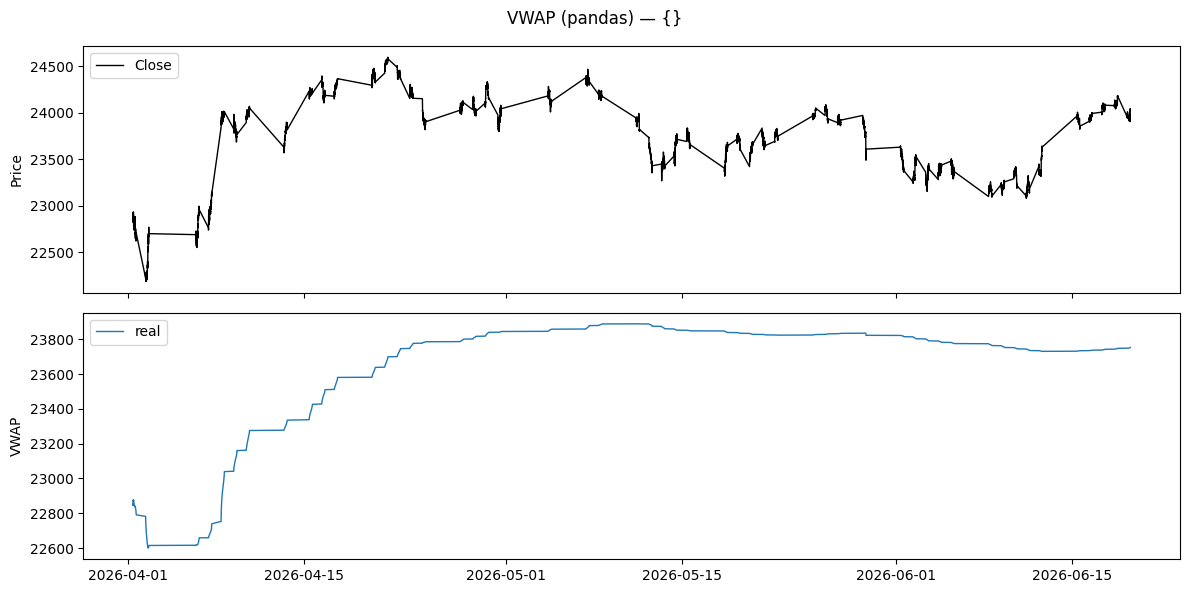

IndicatorResult(name='VWAP', group='Volume Indicators', params_used={}, outputs={'real': array([22854.51666667, 22845.10830853, 22847.48443936, ...,
       23753.09852237, 23753.1416678 , 23753.16870684])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [43]:
test_pandas_indicator("VWAP")


<a id="price-transform"></a>
## Price Transform (4)


### AVGPRICE
Outputs: `['avgprice']` · Defaults: `{}`


AVGPRICE  |  Price Transform  (pandas)
Status: success  |  Warmup: 0
Outputs: ['avgprice']  |  Params: {}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,avgprice
date,,
2026-06-19 15:15:00+00:00,24016.85,24020.0750
2026-06-19 15:16:00+00:00,24018.85,24016.4625
2026-06-19 15:17:00+00:00,24027.60,24022.0250
2026-06-19 15:18:00+00:00,24025.75,24025.5250
2026-06-19 15:19:00+00:00,24028.00,24027.1500
2026-06-19 15:20:00+00:00,24031.15,24030.2125
2026-06-19 15:21:00+00:00,24030.90,24031.5375
2026-06-19 15:22:00+00:00,24027.20,24028.7750
2026-06-19 15:23:00+00:00,24031.65,24029.0000


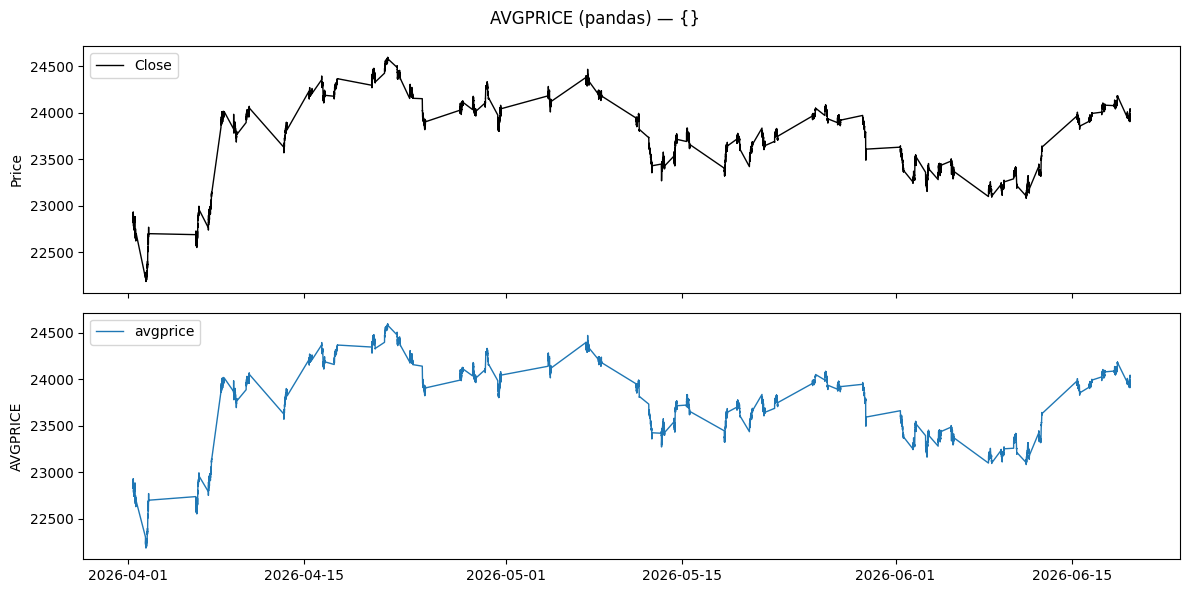

IndicatorResult(name='AVGPRICE', group='Price Transform', params_used={}, outputs={'avgprice': array([22865.6375, 22831.8375, 22848.1125, ..., 24030.7625, 24037.55  ,
       24040.55  ])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [44]:
test_pandas_indicator("AVGPRICE")


### MEDPRICE
Outputs: `['medprice']` · Defaults: `{}`


MEDPRICE  |  Price Transform  (pandas)
Status: success  |  Warmup: 0
Outputs: ['medprice']  |  Params: {}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,medprice
date,,
2026-06-19 15:15:00+00:00,24016.85,24018.825
2026-06-19 15:16:00+00:00,24018.85,24016.000
2026-06-19 15:17:00+00:00,24027.60,24021.325
2026-06-19 15:18:00+00:00,24025.75,24025.000
2026-06-19 15:19:00+00:00,24028.00,24027.000
2026-06-19 15:20:00+00:00,24031.15,24030.650
2026-06-19 15:21:00+00:00,24030.90,24031.775
2026-06-19 15:22:00+00:00,24027.20,24028.000
2026-06-19 15:23:00+00:00,24031.65,24029.225


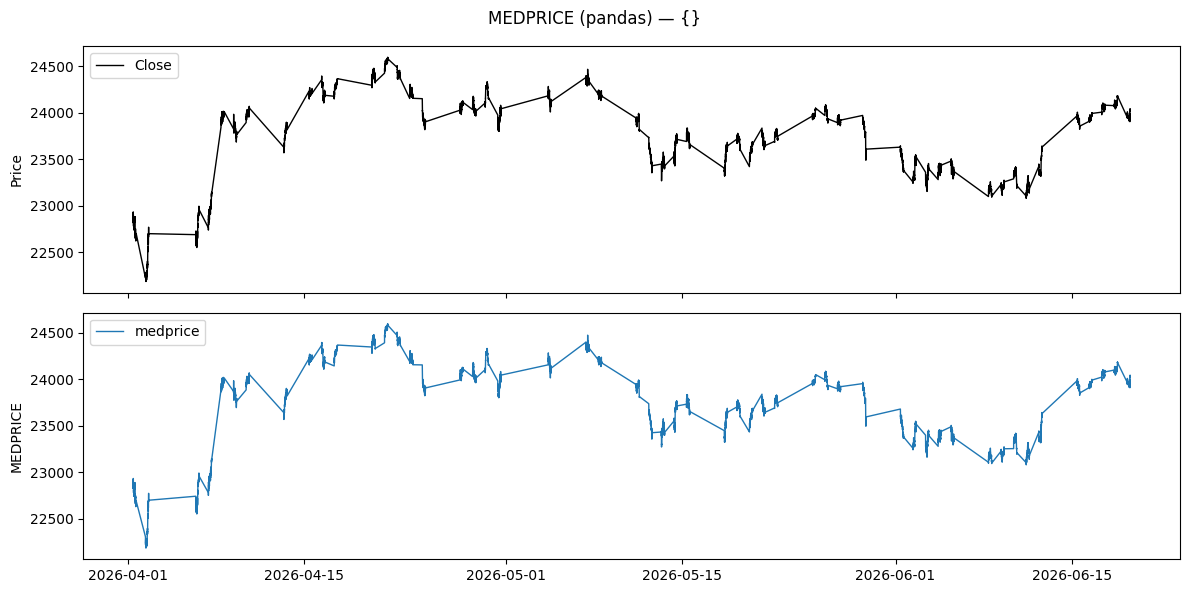

IndicatorResult(name='MEDPRICE', group='Price Transform', params_used={}, outputs={'medprice': array([22860.05 , 22830.15 , 22849.375, ..., 24029.975, 24037.15 ,
       24041.05 ])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [45]:
test_pandas_indicator("MEDPRICE")


### TYPPRICE
Outputs: `['typprice']` · Defaults: `{}`


TYPPRICE  |  Price Transform  (pandas)
Status: success  |  Warmup: 0
Outputs: ['typprice']  |  Params: {}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,typprice
date,,
2026-06-19 15:15:00+00:00,24016.85,24018.166667
2026-06-19 15:16:00+00:00,24018.85,24016.950000
2026-06-19 15:17:00+00:00,24027.60,24023.416667
2026-06-19 15:18:00+00:00,24025.75,24025.250000
2026-06-19 15:19:00+00:00,24028.00,24027.333333
2026-06-19 15:20:00+00:00,24031.15,24030.816667
2026-06-19 15:21:00+00:00,24030.90,24031.483333
2026-06-19 15:22:00+00:00,24027.20,24027.733333
2026-06-19 15:23:00+00:00,24031.65,24030.033333


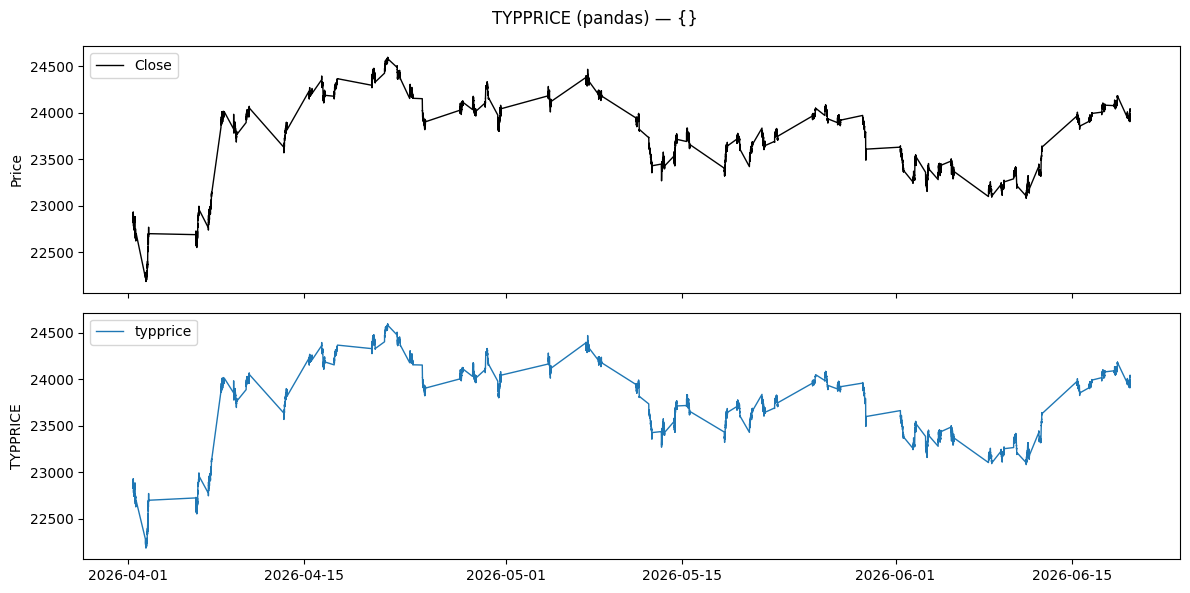

IndicatorResult(name='TYPPRICE', group='Price Transform', params_used={}, outputs={'typprice': array([22854.51666667, 22828.13333333, 22855.93333333, ...,
       24031.85      , 24038.8       , 24041.6       ])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [46]:
test_pandas_indicator("TYPPRICE")


### WCLPRICE
Outputs: `['wclprice']` · Defaults: `{}`


WCLPRICE  |  Price Transform  (pandas)
Status: success  |  Warmup: 0
Outputs: ['wclprice']  |  Params: {}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,wclprice
date,,
2026-06-19 15:15:00+00:00,24016.85,24017.8375
2026-06-19 15:16:00+00:00,24018.85,24017.4250
2026-06-19 15:17:00+00:00,24027.60,24024.4625
2026-06-19 15:18:00+00:00,24025.75,24025.3750
2026-06-19 15:19:00+00:00,24028.00,24027.5000
2026-06-19 15:20:00+00:00,24031.15,24030.9000
2026-06-19 15:21:00+00:00,24030.90,24031.3375
2026-06-19 15:22:00+00:00,24027.20,24027.6000
2026-06-19 15:23:00+00:00,24031.65,24030.4375


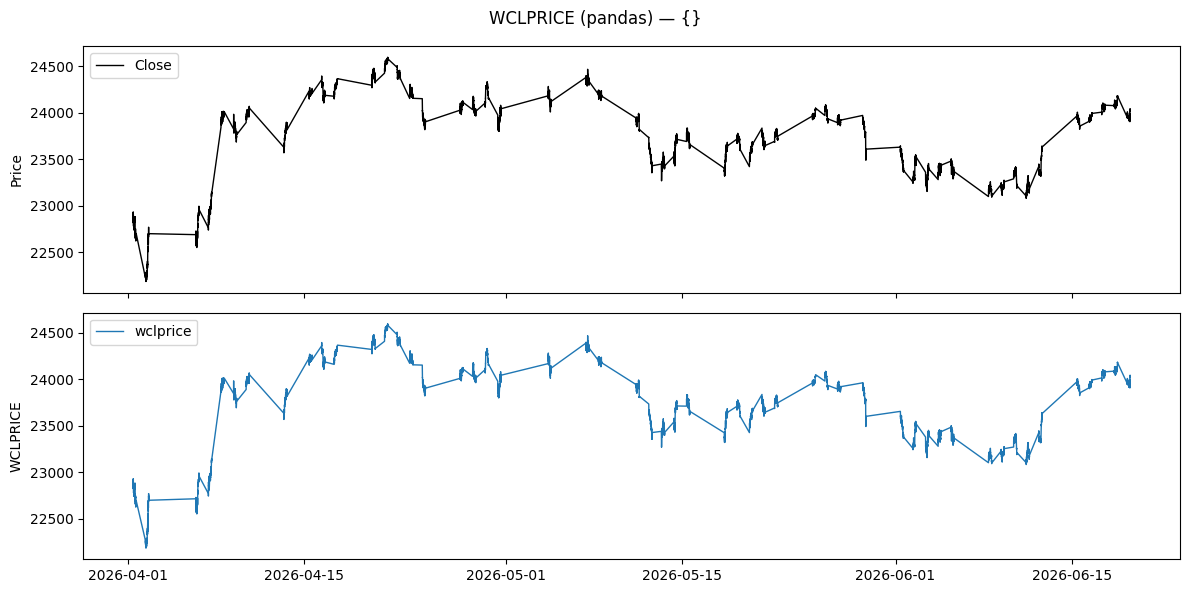

IndicatorResult(name='WCLPRICE', group='Price Transform', params_used={}, outputs={'wclprice': array([22851.75  , 22827.125 , 22859.2125, ..., 24032.7875, 24039.625 ,
       24041.875 ])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [47]:
test_pandas_indicator("WCLPRICE")


<a id="statistic-functions"></a>
## Statistic Functions (4)


### STDDEV
Outputs: `['stddev']` · Defaults: `{'length': 5}`


STDDEV  |  Statistic Functions  (pandas)
Status: success  |  Warmup: 4
Outputs: ['stddev']  |  Params: {'length': 5}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,stddev
date,,
2026-06-19 15:15:00+00:00,24016.85,8.668362
2026-06-19 15:16:00+00:00,24018.85,9.029424
2026-06-19 15:17:00+00:00,24027.60,6.784873
2026-06-19 15:18:00+00:00,24025.75,4.979207
2026-06-19 15:19:00+00:00,24028.00,5.194396
2026-06-19 15:20:00+00:00,24031.15,4.579929
2026-06-19 15:21:00+00:00,24030.90,2.304506
2026-06-19 15:22:00+00:00,24027.20,2.357700
2026-06-19 15:23:00+00:00,24031.65,2.028115


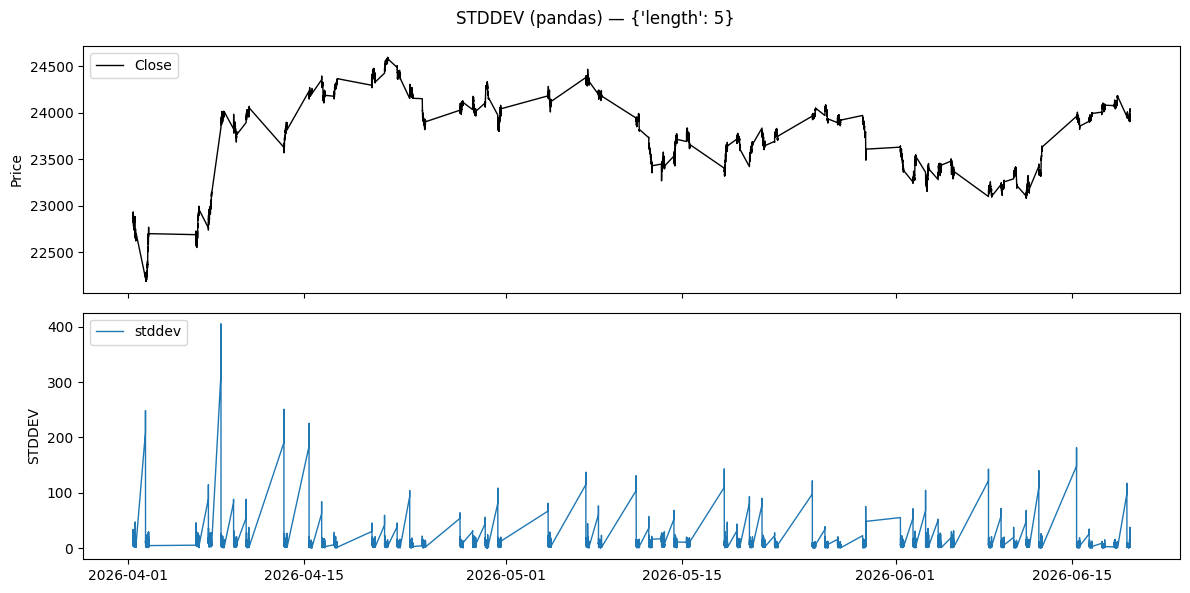

IndicatorResult(name='STDDEV', group='Statistic Functions', params_used={'length': 5}, outputs={'stddev': array([       nan,        nan,        nan, ..., 3.40158054, 5.85657752,
       7.15817716])}, warmup_bars=4, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [48]:
test_pandas_indicator("STDDEV")


### VAR
Outputs: `['var']` · Defaults: `{'length': 5}`


VAR  |  Statistic Functions  (pandas)
Status: success  |  Warmup: 4
Outputs: ['var']  |  Params: {'length': 5}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,var
date,,
2026-06-19 15:15:00+00:00,24016.85,75.14050
2026-06-19 15:16:00+00:00,24018.85,81.53050
2026-06-19 15:17:00+00:00,24027.60,46.03450
2026-06-19 15:18:00+00:00,24025.75,24.79250
2026-06-19 15:19:00+00:00,24028.00,26.98175
2026-06-19 15:20:00+00:00,24031.15,20.97575
2026-06-19 15:21:00+00:00,24030.90,5.31075
2026-06-19 15:22:00+00:00,24027.20,5.55875
2026-06-19 15:23:00+00:00,24031.65,4.11325


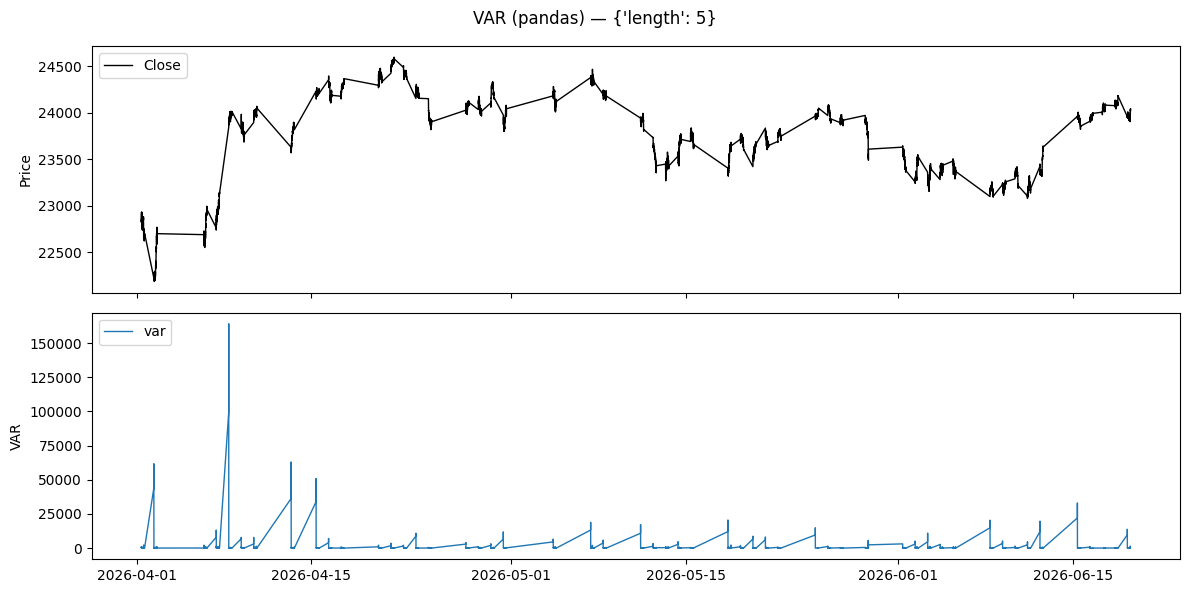

IndicatorResult(name='VAR', group='Statistic Functions', params_used={'length': 5}, outputs={'var': array([       nan,        nan,        nan, ..., 11.5707502, 34.2995002,
       51.2395002])}, warmup_bars=4, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [49]:
test_pandas_indicator("VAR")


### ZSCORE
Outputs: `['zscore']` · Defaults: `{'length': 20}`


ZSCORE  |  Statistic Functions  (pandas)
Status: success  |  Warmup: 19
Outputs: ['zscore']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,zscore
date,,
2026-06-19 15:15:00+00:00,24016.85,0.512944
2026-06-19 15:16:00+00:00,24018.85,0.479170
2026-06-19 15:17:00+00:00,24027.60,0.609438
2026-06-19 15:18:00+00:00,24025.75,0.503071
2026-06-19 15:19:00+00:00,24028.00,0.563951
2026-06-19 15:20:00+00:00,24031.15,0.693323
2026-06-19 15:21:00+00:00,24030.90,0.703736
2026-06-19 15:22:00+00:00,24027.20,0.304324
2026-06-19 15:23:00+00:00,24031.65,0.747242


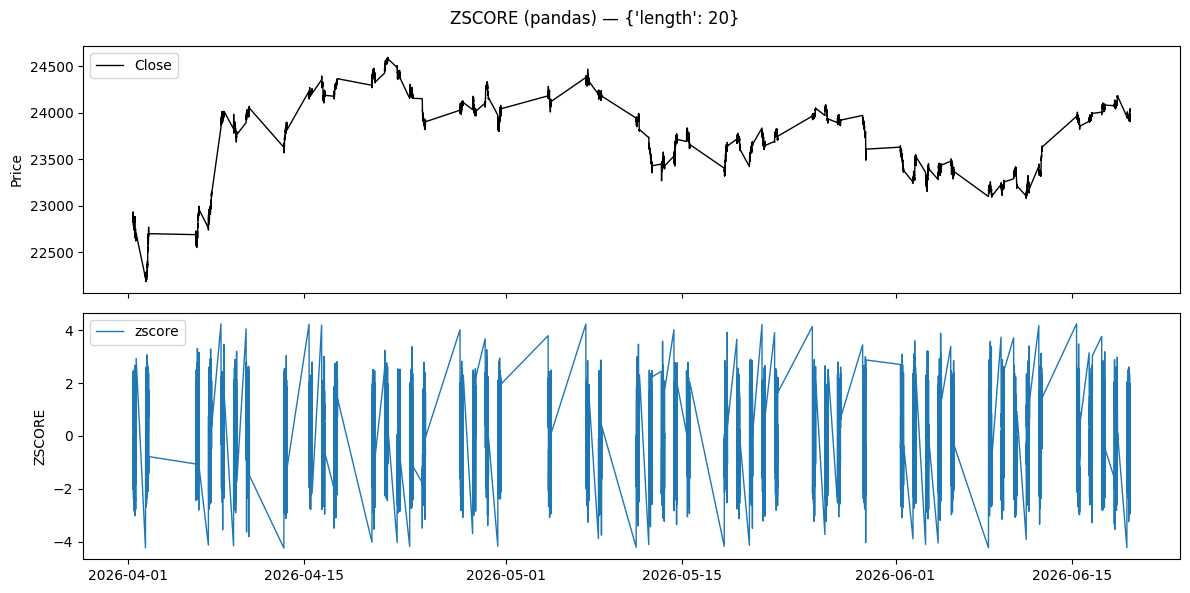

IndicatorResult(name='ZSCORE', group='Statistic Functions', params_used={'length': 20}, outputs={'zscore': array([       nan,        nan,        nan, ..., 1.1826037 , 1.97190112,
       1.79678476])}, warmup_bars=19, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [50]:
test_pandas_indicator("ZSCORE")


### LINEARREG
Outputs: `['linearreg']` · Defaults: `{'length': 14}`


LINEARREG  |  Statistic Functions  (pandas)
Status: success  |  Warmup: 13
Outputs: ['linearreg']  |  Params: {'length': 14}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,linearreg
date,,
2026-06-19 15:15:00+00:00,24016.85,24036.677143
2026-06-19 15:16:00+00:00,24018.85,24032.365714
2026-06-19 15:17:00+00:00,24027.60,24030.235714
2026-06-19 15:18:00+00:00,24025.75,24028.034286
2026-06-19 15:19:00+00:00,24028.00,24027.224286
2026-06-19 15:20:00+00:00,24031.15,24027.300000
2026-06-19 15:21:00+00:00,24030.90,24027.550000
2026-06-19 15:22:00+00:00,24027.20,24026.624286
2026-06-19 15:23:00+00:00,24031.65,24026.637143


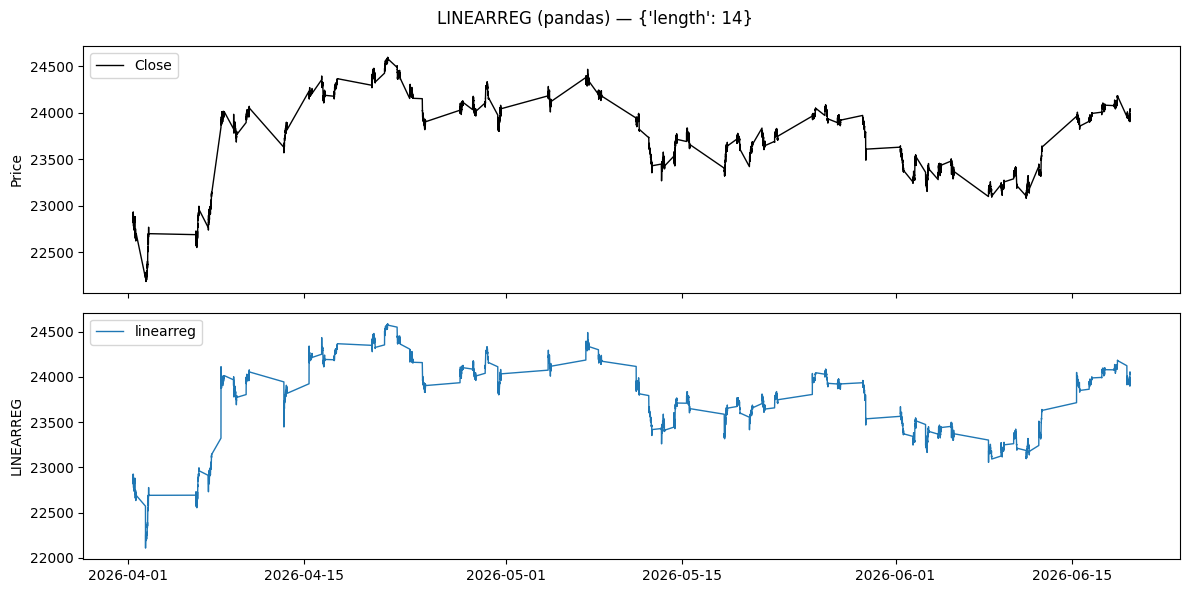

IndicatorResult(name='LINEARREG', group='Statistic Functions', params_used={'length': 14}, outputs={'linearreg': array([           nan,            nan,            nan, ...,
       24033.46857143, 24036.98285714, 24038.77571429])}, warmup_bars=13, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [51]:
test_pandas_indicator("LINEARREG")
